In [163]:
import time
start_time = time.time()

# 🚿 Step 1: Claims Data Preparation 🚿

🎯 **Objective**: Data cleaning of raw PhilHealth e-claims for 2018-2021 so that it can be fed  into the v5 grouper.

▶️ **Input**: Raw e-claims data from TFI amounting to ~40GB (10GB per year_to_load) ◀️
- Google Colab pro+ is required to process 40 GB of data
- If not on Colab pro+ process claims datasets per year_to_load

💾 **Data Set Output**: Pre-processed e-claims data with all needed variables (step before dataset for grouper, see Step 02)
- Preparation: revised column names, removal of unneeded variables, filtering of unneeded observations
- Cleaning:
  - Categorical variables - standardize categories
  - Numeric variables - ensure correct format, CPI adjustment for charges
  - ICD & RVS strings -  remove punctuations, map ICD and RVS codes to TDRG lists,identify principal diagnosis
  - Impute birthweight and ageday for newborns

📒 **Documentation Output for Data Quality** 📒
  - <list out later based on Step 1A in IR>

  
  


## 💻 **A. Workplace Preparations (must always run this section)**


### **1. Decide by answering the fields:**
  * Claims data admission **year_to_load** to process
  * Whether Data Preprocessing section needs to be run
  * Whether to drop outpatient and unpaid/unapproved claims
  * Whether to add labels to numeric categorical codes

In [164]:
# @title
### Decisions for Input
## Provide YEAR of claims data set to process.
# NOTE: this will process each individual file per year_to_load.
year_to_load = 2018

## Drop/filter out outpatient and non paid/approved claims?
# If yes, indicate "True"
subset = False

### **2. Load libraries, GCS, and file paths**
  * Python Libraries and interactive tables extensions for easier data exploration
  * Link to Google Cloud Storage and define file paths
  * Other relevant tables: TDRG v5 libraries, ACR and RVS-to-ICD9CM, auxiliary data

In [165]:
# @title
## Import Software Libraries
#pandas is for data manipulation and analysis operations
import pandas as pd
#NumPy is for operations to manipulate arrays and matrices
import numpy as np
#os is for using operating system dependent functions (e.g. reading and manipulating filepaths and files)
import os
#gc is to enable optional garbage collection to free up objects taking memory
import gc
#string is for operations and functions to manipulate strings
import string
#re is for operations to manipulate regular expressions
import re
# swifter is to apply functions to a dataframe or series in the fastest available manner
# !pip install swifter
import swifter
# datetime is for manipulating dates and times
import datetime
# crmod makes downloaded large files from GCS quicker
# ! pip install crcmod
# random number generator
import random

from pathlib import Path
project_root = Path.cwd().parent

## Interactive Tables - Import Colab extension from pandas dataframes and enable data table display (https://colab.research.google.com/notebooks/data_table.ipynb)
# from google.colab import data_table
# data_table.enable_dataframe_formatter()

In [166]:
# @title
## Authenticate user permissions to access Google Cloud Storage (GCS)
# from google.colab import auth
# auth.authenticate_user()

## Connect to Google Cloud Project with files
# project_id = 'ambient-union-377309'
# !gcloud config set project {project_id}

# ## Define Bucket filepaths -- UNUSED, but good reference
path_raw_claims = project_root / 'git-ignored-files' / 'raw-claims'

sampled_file = path_raw_claims / 'sampled_claims_extract_CLAIMS_2018_sampled_v2_250000.csv'

path_aux = project_root / 'git-ignored-files' / 'aux-files'
path_inter = project_root / 'git-ignored-files' / 'intermediate-claims'
path_i10 = path_aux / 'i10.csv'
path_i10vx = path_aux / 'i10vx.csv'
path_proc = path_aux / 'proc.csv'
path_phil_icd10 = path_aux / 'phil_icd10.csv'
path_phl_acr = path_aux / 'acr_icd10.csv'
path_acr_rvs = path_aux / 'acr_rvs.csv'
path_rvs_icd9cm = path_aux / 'rvs_icd9cm.csv'
path_cache = project_root / 'data-cleaning' / 'cache' / 'python_cache.pkl'
path_cleaned = project_root / 'data-cleaning' / 'cache' / 'python_cleaned.pkl'


# path_preproc_claims = f'gs://01_raw_eclaims/claims_preprocessed/'
# path_aux_data = f'gs://02_auxiliary_data/'
# path_tdrg_lib = f'gs://03_tdrg_v5/'
# path_processed_claims = f'gs://04_processed_claims_for_grouper/'
# path_grouped_claims = f'gs://05_grouped_eclaims/'

### **3. Upload auxiliary data to session from GCS**
* https://www.skytowner.com/explore/reading_file_from_google_cloud_storage_in_google_colab
* https://cloud.google.com/storage/docs/gsutil/commands/cp

In [167]:
## TDRG v5 Tables (.json files) => need to add 2nd lines to create dataframes for these
# 1. All ICD-10 codes with tags of acceptability, min/max age, acceptable age, whether HIV, validity as a CC, whether trauma, MDC, PDC
# !gsutil cp 'gs://03_tdrg_v5/i10.json' .
# tdrg_icd10 = pd.read_json("i10.json", orient='index')
tdrg_icd10 = pd.read_csv(path_i10)

# 2. All ICD-10 codes, text descriptions, and validity as a PDx
# !gsutil cp 'gs://03_tdrg_v5/i10vx.json' .
# tdrg_icd10_d = pd.read_json("i10vx.json", orient='index')
tdrg_icd10_d = pd.read_csv(path_i10vx)
dict_tdrgicd10 = dict(zip(tdrg_icd10_d.code, tdrg_icd10_d.desc)) # Create a dictionary where key=ICD-10, value=text description

# 3. All Procedure (ICD-9CM) codes with description, validity checks, site, MDC, etc.
# !gsutil cp 'gs://03_tdrg_v5/i9.json' .
# tdrg_icd9 = pd.read_json("i9.json", orient='index')
tdrg_icd9 = pd.read_csv(path_proc)

# 4. DRG list
# !gsutil cp 'gs://03_tdrg_v5/drg.json' .
# drg = pd.read_json("drg.json", orient='index')

In [168]:
### Philippine and PhilHealth Code Lists
## 1. ICD-10 2014 Modification, code, disease name, remarks
# !gsutil cp 'gs://01_raw_eclaims/phil_icd10.csv' .
# phl_icd10 = pd.read_csv("phil_icd10.csv", encoding='unicode_escape')
phl_icd10 = pd.read_csv(path_phil_icd10, encoding='iso-8859-1')

# Process dagger asterisk ICD-10 strings: from "B51.0+D77*" to ["B51.0", "D77"]
# phl_icd10['icd10'] = phl_icd10['icd10'].apply(lambda x: x.replace("+",",").replace("*","").split(","))

# For ICD-10 string lists as above, separate strings into rows (i.e., adds another row for the ICD-10)
# https://www.w3resource.com/pandas/dataframe/dataframe-explode.php
# phl_icd10 = phl_icd10.explode('icd10')

## 2. ACR list of ICD-10 codes with reimbursement price
# !gsutil cp 'gs://01_raw_eclaims/acr_icd10.csv' .
phl_acr = pd.read_csv(path_phl_acr)

## 3. RVS list with reimbursement price
# !gsutil cp 'gs://01_raw_eclaims/acr_rvs.csv' .
acr_rvs = pd.read_csv(path_acr_rvs)

## 4. RVS to ICD-9CM Mapping
# !gsutil cp 'gs://01_raw_eclaims/rvs_icd9cm.csv' .
phl_rvs_map = pd.read_csv(path_rvs_icd9cm)

# Make ICD9CM and RVS columns string and remove "."
phl_rvs_map['icd9cm'] = phl_rvs_map['icd9cm'].swifter.apply(lambda x: str(x).replace(".",""))
phl_rvs_map['rvs'] = phl_rvs_map['rvs'].swifter.apply(lambda x: str(x).replace(".0",""))

Pandas Apply:   0%|          | 0/6714 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/6714 [00:00<?, ?it/s]

In [169]:
# @title
### Auxiliary Files
## 1. Accredited Health Facilities
# !gsutil cp 'gs://02_auxiliary_data/2022 Inst - characteristics 06072022.csv' .

# hci_dtype = {'inst_name': 'string', 'inst_type':'category',
#              'inst_own':'category', 'inst_own2': 'category',
#              'psgc_prov':'category', 'psgc_reg' :'category',
#              'psgc_island':'category'}

# aux_hci = pd.read_csv("2022 Inst - characteristics 06072022.csv",
#                       dtype=hci_dtype)
# aux_hci.drop(["inst_mun_lat", "inst_mun_long"], inplace=True, axis=1)

# ## 2. PSA CPI - Inpatient CPI (commodity_index==6 & psgc_level=3 province) only
# !gsutil cp 'gs://02_auxiliary_data/2022 PSA CPI for HEALTH 2018-June 2022 (2018=100).csv' .
# aux_cpi = pd.read_csv('2022 PSA CPI for HEALTH 2018-June 2022 (2018=100).csv',
#                       usecols=['year_to_load', 'psgc_level', 'psgc_prov', 'commodity_index', 'cpi_ave'])

# ## 3. PSA Population and Poverty
# !gsutil cp 'gs://02_auxiliary_data/2022 PSGC Poverty - province muni - 2023 03 21.csv' .
# aux_psgc = pd.read_csv('2022 PSGC Poverty - province muni - 2023 03 21.csv')

# # Convert psgc2022 that read in as float into string
# aux_psgc["psgc2022"] = aux_psgc["psgc2022"].apply(lambda x: str(x).replace(".",""))

In [170]:
## Compile all the possible diagnosis and procedure codes into sets so they're easier to reference
# 1. ICD-10 Codes
thai_i10 = set(tdrg_icd10.CODE.str.replace(".","").str.upper())
acr_i10 = set(phl_acr.icd10.str.replace(".","").str.upper())
phl_i10 = set(phl_icd10.icd10.str.replace(".","").str.upper())
all_i10 = thai_i10 | acr_i10 | phl_i10

# 2. Procedure Codes
phl_rvs = set(acr_rvs.rvs)
thai_i9 = set(tdrg_icd9.CODE)
rvs_i9 = set(phl_rvs_map.icd9cm)
all_proc = thai_i9 | rvs_i9

In [171]:
## Additional Special PhilHealth RVS codes
covid_rvs = {'C19T1', 'C19T2',' C19T3', 'C19X1', 'C19X2', 'C19X3', 'C19FRP',
             'C19IP1', 'C19IP2', 'C19IP3', 'C19IP4',
             'C19PP1', 'C19PP2', 'C19PP3', 'C19PP4',
             'MP01', 'IMP02', 'C19CI', 'C19H1', 'C19VIH', 'C19VID'
             }

# Update phl_rvs
phl_rvs.update(covid_rvs)

## 🔧 **B. Data Processing (takes the longest time)**

### **1. Load raw e-claims data**

In [172]:
# @title
# Declare Filename for CLEANED e-claims file
# cleaned_file = f'claims_cleaned_{year_to_load}.csv'

# LIST of all files in the pre-processed claims folder
# preproc_claims_list = !gsutil ls {path_preproc_claims}

In [173]:
# @title
# Load Raw e-claims csv into LOCAL COLAB directory
# Estimated time: 3-5 minutes
# if cleaned_file not in preproc_claims_list:
#    # File name for raw e-claims file
#   raw_file_read = f'CLAIMS*{year_to_load}.csv' # to load from GCS (* represents space)
#   raw_file = f'CLAIMS {year_to_load}.csv' # to check in local directory

# Check if raw file is loaded already in the LOCAL COLAB directory
# if raw_file not in os.listdir():
#   # Specify filepath and filename pattern
#   raw_file_path = f'{path_raw_claims}{raw_file_read}'
#   # Copy raw e-claims file for <year_to_load> into LOCAL COLAB directory
#   # !gsutil cp {raw_file_path} .

### **2. Load/Create pandas dataframe `df`**

In [174]:
# @title
## Declare Columns to Load
# Drops HCP_NO_LIST, EMERGENCY, 'PAT_BWT_KG', MEMCAT_SUBCHILD_DESC, EXTRACTION_DATE, ICDCODE27-170
# From 200 columns to 69
usecols = ['PSEUDO_CLAIMSERIES', 'PSEUDO_MEM_PIN',
            'DATE_ADM','TIME_ADM', 'DATE_DIS', 'TIME_DIS',
            'DATE_REC', 'DATE_REF', 'CHKDT',
            'HCI_PMCC_NO', 'OUT_PATIENT',
            'PATIENT_TYPE', 'ROOM_TYPE', 'DEP_REL', 'PAT_BDAY',
            'PATAGE', 'PATSEX', 'MEMCAT_PARENT_DESC', 'MEMCAT_CHILD_DESC',
            'DISPOSITION', 'PRIMARY_ILLNESS', 'SECONDARY_ILLNESS',
            'CLAIMS_STATUS', 'CLAIMS_PAID_AMT', 'ACR_AMOUNT_ACTUAL']

icd = [f'ICDCODE{i}' for i in range(1,13)]\
            + [f'RVSCODE{i}' for i in range(1,21)]
# icd.remove("ICDCODE15")   # Wrong column name provided by TFI in raw dataset

usecols = usecols + icd

In [175]:
# @title
## Declare Data Types to reduce RAM consumption while loading as pandas dataframe
# https://pandas.pydata.org/docs/user_guide/basics.html#basics-dtypes
# https://vincentteyssier.medium.com/optimizing-the-size-of-a-pandas-dataframe-for-low-memory-environment-5f07db3d72e
dtype = {}

# Strings
strings = ['PSEUDO_CLAIMSERIES', 'PSEUDO_MEM_PIN', 'HCI_PMCC_NO',
           'PRIMARY_ILLNESS', 'SECONDARY_ILLNESS'] + icd
for var in strings:
  dtype[var] = "string"

# Categoricals
cat = ['OUT_PATIENT', 'PATIENT_TYPE',
       'ROOM_TYPE', 'DEP_REL', 'PATSEX',
       'MEMCAT_PARENT_DESC', 'MEMCAT_CHILD_DESC',
       'DISPOSITION', 'CLAIMS_STATUS', ]
for var in cat:
  dtype[var] = "category"

# Downcast Floats
dtype['PATAGE'] = "float16"
dtype['CLAIMS_PAID_AMT'] = "float32"
dtype['ACR_AMOUNT_ACTUAL'] = "float32"

In [176]:
# @title
# ## Load ENTIRE CSV with as pandas df
# Run Time: 5 minutes
# "ISO-8859-1" means  "tab" as the delimited and standard encoding

raw_file = sampled_file

df = pd.read_csv(raw_file, encoding='ISO-8859-1', dtype=dtype, usecols=usecols,
                 na_values=['NONE','None','',' ','-','--','---','N/A','n/a','nan','NAN']
                 # nrows=3000000  # For Loading only <nrows> number of rows
                 )

In [177]:
# # @title
# # ## Load ENTIRE CSV with as pandas df
# # Run Time: 5 minutes
# # "ISO-8859-1" means  "tab" as the delimited and standard encoding
# if 'df' not in locals():
#     df = pd.read_csv(raw_file, encoding='ISO-8859-1',  usecols=['CLAIMS_STATUS'],
#                      na_values=['NONE','None','',' ','-','--','---','N/A','n/a','nan','NAN']
#                      # nrows=3000000  # For Loading only <nrows> number of rows
#                      )

### **3. Rename variable columns**

In [178]:
# @title
## Rename columns in original file to names of variables in codebook (e.g. 'pseudo_claimseries':'id_series') and store in array to be reference again
# Create Dictionary Matching Old Column Names with New Names
col_rename = {
    'PSEUDO_CLAIMSERIES': 'id_series',
    'PSEUDO_MEM_PIN': 'id_pin',
    'DATE_ADM': 'date_adm',
    'TIME_ADM': 'time_adm',
    'DATE_DIS': 'date_dis',
    'TIME_DIS': 'time_dis',
    'DATE_REC': 'date_rec',
    'DATE_REF': 'date_ref',
    'CHKDT': 'date_check',
    'EXTRACTION_DATE': 'date_ext',
    'HCI_PMCC_NO': 'id_hci',
    'HCP_NO_LIST': 'id_hcp',
    'PATIENT_TYPE': 'pat_type',
    'DEP_REL': 'pat_rel',
    'PATSEX': 'pat_sex',
    'PATAGE': 'pat_age',
    'PAT_BDAY': 'pat_bdate',
    'PAT_BWT_KG': 'pat_bwt',
    'MEMCAT_PARENT_DESC': 'pat_memcat_parent',
    'MEMCAT_CHILD_DESC': 'pat_memcat_child',
    'MEMCAT_SUBCHILD_DESC': 'pat_memcat_subchild',
    'OUT_PATIENT': 'clin_outpatient',
    'EMERGENCY': 'clin_emergency',
    'ROOM_TYPE': 'clin_acc',
    'DISPOSITION': 'clin_discharge',
    'PRIMARY_ILLNESS': 'clin_c1',
    'SECONDARY_ILLNESS': 'clin_c2',
    'CLAIMS_STATUS': 'claim_status',
    'ACR_AMOUNT_ACTUAL': 'claim_charge',
    'CLAIMS_PAID_AMT': 'claim_payout'
}

# Handle the dynamic column renaming for ICDCODE1-12 and RVSCODE1-20
for i in range(1, 13):
    col_rename[f'ICDCODE{i}'] = f'clin_icd{i}'
    
for i in range(1, 21):
    col_rename[f'RVSCODE{i}'] = f'clin_rvs{i}'
    
# Assuming df is your DataFrame
df.rename(columns=col_rename, inplace=True)

# Print the first few rows to verify
# print(df.head())

In [179]:
# @title
## Rename columns
# "inplace=True" is indicated to modify columns within existing dataframe.
# df.rename(columns=col_rename, inplace=True)

### **4. Merge 2022 PhilHealth Accredited Facilities Characteristics**

In [180]:
# @title
# Merge using institution code
# "Left" - keeps all rows from df - matched and not matched
# df = df.merge(aux_hci, on="inst_code" , how='left')

In [181]:
# @title
# List Institution Variables
# inst_mask = ["inst_code", "inst_name", "psgc_island", "psgc_reg", "psgc_prov",
#              "inst_type", "inst_own", "inst_own2"]

In [182]:
# @title
## ERROR: Institution Codes that start with "IHxxxx" are not in our HCI dataset
# df2.loc[df2["inst_name"].isna(), inst_mask].head(1000)
# df[df["inst_name"].isna()]["inst_code"].value_counts()

In [183]:
# @title
## ERROR in Tagging of "out_patient=1"
# There claims outside of hospitals tagged as inpatient
# pd.crosstab(df["inst_type"], df["clin_outpatient"])

In [184]:
# @title
# Overwrite df with df2 and cleanup RAM
# del(aux_hci)
# gc.collect()

### **5. Drop unneeded columns and rows**

In [185]:
# @title
# DISABLED - already done in step 2
# ## Drop Excessive ICD-10 Columns
# if redo:
#   # Drop ICD codes 27 to 170 which are mostly empty; NOTE: axis= 1 refers to columns
#   df.drop(df.loc[:,'clin_icd27':'clin_icd170'].columns, inplace=True, axis=1)

#   # Drop other columns that are not needed for analyzing claims
#   df.drop(['inst_code_list', 'pat_type_rel', 'date_extraction', 'pat_cat3'], inplace=True, axis=1)

#   #Clear memory allocated for objects no longer being used
#   gc.collect()

**Subset the Claims**
- Claim Status: paid or approved for payment
- Inpatient claims
- Facility type: hospitals L1 to L3, infirmaries


In [186]:
## Subset to Eligible Claims: Inpatient and Paid/Approved Claims
# Temporary data frame with only relevant rows
# df = df.loc[(df['clin_outpatient'] == "0") &
#                  (df['claims_status'].isin(['PAID', 'APRV4PAYMENT'])) &
#                  (df['inst_type'].str.contains('LEVEL|INFIRMARY', na=False))
#                  ]

# # Drop additional columns that are not needed within the specific subset
# df.drop(['clin_outpatient', 'claims_status'], inplace=True, axis=1)

# # Clear memory allocated for objects no longer being used
# gc.collect()

In [187]:
# @title
# Output value counts
# df['inst_type'].value_counts()

### **6. Fix date and numeric variables**

In [188]:
## Explore and Correct Birthdates with Invalid Years
# This causes an error in the pd.to_datetime command in the next cell
## Scratch Cel Exploration Code to identify and Birthday Years < 1000 (e.g. 0942)
  # df['age_year']= df['pat_bdate'].str.strip().str[-4:].astype("Float32")
  # df2 = df.loc[df['age_year'] < 1000, ['pat_bdate', 'age_year']]
  # df2.head()
  # # Print head to check that it worked
  # df.loc[df['age_year'] < 1000, ['pat_bdate', 'age_year']].head()
  # # Drop 'age_year'
  # df.drop(['age_year'], inplace=True, axis=1)

## Replace 0YYYY with 1YYYY for valid year_to_load -re doesnt work yet
# df['pat_bdate_1'] = df['pat_bdate'].astype(str).re.sub(r"[0][8-9][0-9][0-9]",r"[1][8-9][0-9][0-9]")
# df['pat_bdate'] = df['pat_bdate'].astype(str).str.replace("/09","/19")

In [189]:
## Combine date and time variables and convert to date using pandas "to_datetime" function
# Run Time: ~ 25 minutes for 7.7m observations
# Date Admitted
# df["date_adm"] = pd.to_datetime(df["date_adm"] + " " + df["time_adm"])

# Date Discharged
# df["date_dis"] = pd.to_datetime(df["date_dis"] + " " + df["time_dis"])

In [190]:
# @title
# Other dates
# list of date columns
# date_mask = df.columns[df.columns.str.contains('date')]

# # errors=coerce means we are setting birthdates < 1800 to NaT
# df[date_mask] = df[date_mask].swifter.apply(lambda x: pd.to_datetime(x, errors="coerce"))

# # Drop time columns
# df.drop(["time_adm", "time_dis"], inplace=True, axis=1)

In [191]:
# @title
# Generate Year and Month
# df["year_to_load"] = df["date_adm"].dt.year_to_load.astype('str')
# df["month"] = df["date_adm"].dt.month.astype('str')

In [192]:
# @title
# ## Generate Length of Stay in Days (Float)
# # Get the difference of date of discharge and admission
# df["los"] = df['date_dis'] - df['date_adm']   # format: time delta

# # Calculate the LOS, includes the hours less than a day
# df["clin_los"] = df["los"].dt.days.astype('float16') + \
#                    (df["los"].dt.seconds.astype('float16') / (3600*24))
# df["clin_los"] = df["clin_los"].astype("float16")

# # Drop "los" variable
# df.drop("los", inplace=True, axis=1)

### **7. Fix categorical variables**

In [193]:
# @title
## List of Categorical variables for encoding
# cat_mask = ['pat_type', 'pat_sex','pat_accomodation', 'pat_cat', 'pat_cat2', 'clin_discharge']

In [194]:
# @title
## ENCODE categoricals: use "map" function to SUBSTITUTE numeric values with labels
# (https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
# Use "Int64" if you have NaNs in the variable

# Patient type
df['pat_type'] = df['pat_type'].map({'MEMBER': 'MEM', 'DEPENDENT': 'DEP'})

# Patient Sex
# df['pat_sex'] = df['pat_sex'].map({'M' : 0, 'F': 1}).astype('Int64')

# Accomodation Type
# df['pat_accomodation'] = df['pat_accomodation'].map({'W': 0, 'P': 1}).astype('Int64')

# Membership Category
df['pat_memcat_parent'] = df['pat_memcat_parent'].map({'DIRECT CONTRIBUTOR': 'DIRECT', 'INDIRECT CONTRIBUTOR' : 'INDIRECT'})

In [195]:
# @title
### Fix Membership Subcategories
# Make an object temporarily
df['pat_memcat_child']=df['pat_memcat_child'].astype("object")

# Replace values
# na=False skips over "NaN" rows, or else it will throw an error
# Use ".loc" to locate substrings within membership sub-category column and replace with appropriate label
df.loc[df['pat_memcat_child'].str.contains('EMPLOYED|DRIVER|HOUSEHOLD HELP|KASAMBAHAY|PROFESSIONAL|FORMAL', na=False), 'pat_memcat_child'] = 'FORMAL'
df.loc[df['pat_memcat_child'].str.contains('MIGRANT|SELF-EARNING|SELF EARNING|DUAL CITIZENSHIP|FOREIGN NATIONAL|INFORMAL', na=False), 'pat_memcat_child'] = 'INFORMAL'
df.loc[df['pat_memcat_child'].str.contains('LIFETIME', na=False), 'pat_memcat_child'] = 'LIFETIME'
df.loc[df['pat_memcat_child'].str.contains('INDIGENT', na=False), 'pat_memcat_child'] = 'INDIGENT'
df.loc[df['pat_memcat_child'].str.contains('SPONSORED', na=False), 'pat_memcat_child'] = 'SPONSORED'
df.loc[df['pat_memcat_child'].str.contains('SENIOR CITIZEN', na=False), 'pat_memcat_child'] = 'SENIOR'

# Return back to category type to reduce memory
df['pat_memcat_child'] = df['pat_memcat_child'].astype('category')

In [196]:
# @title
## Map Clinical Disposition at Discharge to v5 grouper categories
# Convert to Object Temporarily
df['clin_discharge']=df['clin_discharge'].astype("object")
disch_mapping = {
      'IMPROVED': 1, # With approval
      'RECOVERED': 1, # With approval
      'HOME/DISCHARGED AGAINST MEDICAL ADVICE': 2, # Against advise
      'ABSCONDED': 3, # Escape
      'TRANSFERRED/REFERRED': 4, # Transfer
      'EXPIRED': 9, # Dead no autopsy
      'UNDEFINED': None # Missing
      }

with_disposition = df["clin_discharge"].notnull()
df.loc[with_disposition, 'clin_discharge'] = df.loc[with_disposition, 'clin_discharge'].swifter.apply(
      lambda x: disch_mapping[x] if x in disch_mapping else x)

# Convert to Integer
df["clin_discharge"] = df["clin_discharge"].astype('Int8')

Pandas Apply:   0%|          | 0/249898 [00:00<?, ?it/s]

### **8. Remove punctuations from ICD & RVS strings**

In [197]:
# @title
## Drop columns with all NA in Data Frame => the excess ICD and RVS columns
# df.dropna(axis=1, how='all', inplace=True)

# Check what was dropped
# df.info()

In [198]:
# @title
## Create Lists for all ICD and RVS variables
icd_mask = df.columns[df.columns.str.contains('c1|c2|icd')]
rvs_mask = df.columns[df.columns.str.contains('clin_rvs')]
codes_mask = df.columns[df.columns.str.contains('clin_rvs|c1|c2|icd')]

In [199]:
# @title
## Remove Punctuations that is not "/"
# Regular expression syntax (https://docs.python.org/3/howto/regex.html#regex-howto)
# Runtime: 20 minuets

#^ = Matches pattern at the beginning of lines. Can also be used within [] to indicate all characters that are not within the set will be matched.
#\w = Matches any alphanumeric character [a-zA-z0-9-]
#\d = Match any decimal digit equivalent to the class [0-9]
#\ = Used to signal special sequences following backslash (e.g.\w) or to escape other metacharacters that are part of the pattern (e.g.\[])
#/ = Used to signal boundaries and escape special characters in a regular expression
#\s = Any whitespace character
#+ = Matches pattern one or more times
#[] = Used to indicate character classess that will be used for matching
#\n = Indicates a new line

# Define function for removing punctuation marks in ICD codes
def remove_punctuation(x):
  # If string is NaN or None or <NA>, return <NA>
  if str(x) == 'nan' or x is None or x is pd.NA :
    return None
  return re.sub(r"[^\w\d\/\s]+", "", x)

## For all ICD code columns, ensure that all string is uppercase
# Remove any white spaces, and remove any extra lines
for col in codes_mask:
    df[col] = df[col].astype(str).str.upper().str.strip().str.replace(" ","").str.replace("\n","").swifter.apply(
        lambda x: None if str(x).lower() in(['nan','none','na','n/a','-','',' ','  ',"'"]) else remove_punctuation(x))

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

...

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

In [200]:
# @title
## Save an original clin_c1 and clin_c2
df["xorig_cr1"] = df["clin_c1"]
df["xorig_cr2"] = df["clin_c2"]

### **Checkpoint: Pickle and save `claims_subset_{year_to_load}` to GCS**

In [201]:
# @title
## Check everything
df.info()
gc.collect()
pd.set_option('display.max_columns', None)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 59 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   id_series          250000 non-null  string  
 1   id_pin             250000 non-null  string  
 2   date_adm           250000 non-null  object  
 3   time_adm           249996 non-null  object  
 4   date_dis           250000 non-null  object  
 5   time_dis           249996 non-null  object  
 6   date_rec           249981 non-null  object  
 7   date_ref           28799 non-null   object  
 8   date_check         232705 non-null  object  
 9   id_hci             250000 non-null  string  
 10  clin_outpatient    249996 non-null  category
 11  pat_type           250000 non-null  category
 12  clin_acc           241331 non-null  category
 13  pat_rel            96354 non-null   category
 14  pat_bdate          195052 non-null  object  
 15  pat_age            250000 non-null

,id_series,id_pin,date_adm,time_adm,date_dis,time_dis,date_rec,date_ref,date_check,id_hci,clin_outpatient,pat_type,clin_acc,pat_rel,pat_bdate,pat_age,pat_sex,pat_memcat_parent,pat_memcat_child,clin_discharge,clin_c1,clin_c2,clin_icd1,clin_icd2,clin_icd3,clin_icd4,clin_icd5,clin_icd6,clin_icd7,clin_icd8,clin_icd9,clin_icd10,clin_icd11,clin_icd12,clin_rvs1,clin_rvs2,clin_rvs3,clin_rvs4,clin_rvs5,clin_rvs6,clin_rvs7,clin_rvs8,clin_rvs9,clin_rvs10,clin_rvs11,clin_rvs12,clin_rvs13,clin_rvs14,clin_rvs15,clin_rvs16,clin_rvs17,clin_rvs18,clin_rvs19,clin_rvs20,claim_status,claim_payout,claim_charge,xorig_cr1,xorig_cr2
0,0000047245381,00000000000016826399,11/20/2018,18:00,11/25/2018,15:15,01/04/2019,NaN,01/10/2019,231701,0,DEP,W,C,NaN,10.0,M,INDIRECT,INDIGENT,1,A971,NA,A971,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,PAID,10000.0,6918.500000,A971,NA
1,0000024403330,00000000000008432267,12/27/2018,19:20,01/08/2019,15:50,03/07/2019,NaN,03/19/2019,520101,0,MEM,W,NaN,02/12/1950,68.0,M,INDIRECT,INDIGENT,1,I219,NA,I219,I499,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,PAID,18900.0,32022.919922,I219,NA
2,0000041400502,00000000000015013020,04/09/2018,07:00,04/09/2018,00:00,06/07/2018,NaN,11/06/2018,640129,1,MEM,P,NaN,02/24/1953,65.0,F,INDIRECT,SENIOR,1,90935,NA,N185Z491,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,90935,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,PAID,2600.0,4800.000000,90935,NA
3,0000002788291,00000000000001023751,04/06/2018,08:00,04/09/2018,08:00,05/24/2018,NaN,07/31/2018,312435,1,MEM,P,NaN,11/20/1953,64.0,M,INDIRECT,SENIOR,1,90935,NA,N185,Z491,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,90935,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,PAID,5200.0,5200.000000,90935,NA
4,0000043010321,00000000000015425482,09/12/2018,06:57,09/12/2018,10:29,10/15/2018,NaN,10/25/2018,Z00504,1,MEM,P,NaN,01/18/1955,63.0,M,INDIRECT,SENIOR,1,90935,NA,N185,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,90935,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,PAID,2600.0,2600.000000,90935,NA


In [202]:
# @title
# Pickle files - data type of each column is retained when we save and load the DataFrame
# https://www.statology.org/pandas-save-dataframe/#:~:text=The%20benefit%20of%20using%20pickle,original%20state%20of%20the%20DataFrame.
subset_file = path_cache
# df.to_pickle(subset_file)
# !gsutil cp $subset_file 'gs://04_processed_claims_for_grouper/'

## 😾 **C. Further cleaning of ICD and RVS codes 🧹**

### **1. Load subsetted data (if can skip 'Data Processing' section)**

In [203]:
# @title
if 'df' not in locals():
  subset_file = path_cache
  if subset_file not in os.listdir():
    subset_path = path_cache
    # !gsutil cp $subset_path .

  # Create the pandas data frame
  df = pd.read_pickle(subset_file)
  df.reset_index(drop=True, inplace=True)

### **2. RVS codes - collate into one column as list**
- Running this code first makes ICD-10 declumping much easier.

In [204]:
## Check if there are errors in RVS codes
# Basis: they contain more than 5 digits (RVS codes are only 5 digits)
rvs = set()
for i in df.columns[df.columns.str.contains('clin_rvs')]:
  rvs = rvs | set(df[i])

# Notes:
# 2018: n=28 invalid codes (6 digits, few ICD-10 codes)
b = []
for x in rvs:
  if len(str(x)) > 5 and x not in phl_rvs:
    b.append(x)

print("There were " + str(len(b)) + " invalid RVS codes detected.")
print(b)

There were 7 invalid RVS codes detected.
['NSDD01', 'Z0156A1', '294345', '903935', '993432', 'P00001', 'HEMODI']


In [205]:
## Declare columns to operate on
# Runtime: ~ 10 minutes
check_cols = df.columns[df.columns.str.contains('rvs|c1|c2')]

## Define the function that will collate the list of ICD-10 codes
def rvs_lister(row, rvs_columns=check_cols):
  rvs_list = []                   # Initialize value of new variable
  for i in rvs_columns:           # Go through rvs w/ index i
    # If the value is not NA, is a valid RVS, is not a duplicate
    if str(row[i]) != "NA":
      if str(row[i]) in phl_rvs:
        if str(row[i]) not in rvs_list:
          rvs_list += [str(row[i])]   # Add RVS to rvs_list cell
  return rvs_list                     # Input the final list as rvs_list cell

## Call Function: Creates a Column with all the ICD codes called "rvs_list"
df['rvs_list'] = df.swifter.apply(rvs_lister, axis=1)

## Mark of contents of c1 or c2 were RVS
# Implication: if both are RVS, then the PDx has to be guessed entirely
df.loc[df["clin_c1"].isin(phl_rvs), "clin_cr1_rvs"] = True
df.loc[df["clin_c2"].isin(phl_rvs), "clin_cr2_rvs"] = True


## Delete contents of c1 and c2 if they are procedures
df.loc[df["clin_c1"].isin(phl_rvs), "clin_c1"] = None
df.loc[df["clin_c2"].isin(phl_rvs), "clin_c2"] = None

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

In [206]:
# @title
## Check Output
# Empty lists translates to False
print(df["clin_cr1_rvs"].value_counts())
df.loc[(df['rvs_list'].astype(bool)==True), df.columns[df.columns.str.contains('rvs|c1|c2')]].head(5)

clin_cr1_rvs
True    140903
Name: count, dtype: int64


,clin_c1,clin_c2,clin_rvs1,clin_rvs2,clin_rvs3,clin_rvs4,clin_rvs5,clin_rvs6,clin_rvs7,clin_rvs8,clin_rvs9,clin_rvs10,clin_rvs11,clin_rvs12,clin_rvs13,clin_rvs14,clin_rvs15,clin_rvs16,clin_rvs17,clin_rvs18,clin_rvs19,clin_rvs20,rvs_list,clin_cr1_rvs,clin_cr2_rvs
2,None,NA,90935,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,[90935],True,NaN
3,None,NA,90935,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,[90935],True,NaN
4,None,NA,90935,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,[90935],True,NaN
5,None,NA,59514,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,[59514],True,NaN
6,None,NA,NSD01,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,[NSD01],True,NaN


In [207]:
# @title
## Delete the clin_rvs1-12 columns
rvs_mask = df.columns[df.columns.str.contains('clin_rvs')]
df.drop(rvs_mask, inplace=True, axis=1)
gc.collect()

26

### **3. ICD-10 Delist lumps of codes (Ex. "N18J189", "O809Z737") into Separate Columns**

**A. Process any lumped codes in `clin_c1` and `clin_c2` separately**
- Reason: these are strong candidates for PDx

In [208]:
## List all ICD-10 codes that need to be delisted
icds = set(df['clin_c1']) | set(df['clin_c2'])

## Identify a set of  of clumped ICD codes
# Criteria: string > 4 characters, not an rvs, > 1 letter, > 1 digit
to_delist = set([x for x in icds if isinstance(x, str)
                 and x not in phl_rvs # includes ANC01, NSD01, FP001, etc.
                 and len(x) > 4
                 and len([i for i in x if i in string.ascii_uppercase]) > 1
                 and len([i for i in x if i in string.digits]) > 1])

## Find all the rows with lumped up lists
delist_mask = (df['clin_c1'].isin(to_delist)) | (df['clin_c2'].isin(to_delist))

## Print Number of rows with lumped c1 and c2 codes
# 2018: n=21,394
# 2019:
print(f'There are {len(df[delist_mask])} rows with lumped up lists of ICD-10 codes.')

There are 570 rows with lumped up lists of ICD-10 codes.


In [209]:
## Data Frame: take the rows with grouped up codes
# Key: id_series
icd_columns = ['clin_c1', 'clin_c2']
icd_series = ["id_series"] + icd_columns

In [210]:
## Function: produce list of ICD-10 codes
# re.findall(pattern, string, flags=0) => returns a string
# Finds all non-overlapping matches of PATTERN in a string from left to right

# Parse either clin_c1 or clin_c2 and return a list of the clumped ICD codes
df.loc[delist_mask, 'c1_list'] = df['clin_c1'].swifter.apply(
    lambda x: [s for s in re.findall('[A-Z][0-9][0-9]*', str(x)) # if s in all_i10
    ])
df.loc[delist_mask, 'c2_list'] = df['clin_c2'].swifter.apply(
    lambda x: [s for s in re.findall('[A-Z][0-9][0-9]*', str(x)) # if s in all_i10
    ])

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

In [211]:
## Make clin_c1 and clin_c2 a list
# For those with only 1 RVS
df.loc[((~delist_mask) & (df['clin_c1'].notnull())), 'clin_c1'] = df['clin_c1'].swifter.apply(lambda x: str(x).split(","))
df.loc[((~delist_mask) & (df['clin_c2'].notnull())), 'clin_c2'] = df['clin_c2'].swifter.apply(lambda x: str(x).split(","))

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

In [212]:
## Copy c1_list and c2_list to clin_c1 and clin_c2 if it was lumped
df.loc[delist_mask, 'clin_c1'] = df['c1_list']
df.loc[delist_mask, 'clin_c2'] = df['c2_list']

## Drop c1_list and c2_list
df.drop(['c1_list', 'c2_list'], inplace=True, axis=1)
gc.collect()

## Check Output
x  = df.columns[df.columns.str.contains('c1|c2')]
df.loc[delist_mask, x]
# df.loc[~delist_mask, x]

# Run in scratch cell, only a few clin_c2 cells have values
# df.loc[delist_mask, "clin_c2"].value_counts()

,clin_c1,clin_c2
30,"[J1899, Y95]",[]
191,"[J1899, Y95]",[]
664,"[E142, N083]",[]
792,"[J1899, Y95]",[I615]
1031,"[J1899, Y95]",[]
...,...,...
246378,"[J1899, Y95]",[]
246658,"[J1899, Y95]",[]
247264,"[J1899, Y95]",[]
247893,"[B371, J172]",[]


**B. Process any lumped codes in `clin_icd1-26` columns**

In [213]:
## List all ICD-10 codes that need to be delisted
# Basis: they contain more than one letter
# Create a set that lists all codes in the icd columns
icds = set()
for i in df.columns[df.columns.str.contains('clin_icd')]:
  icds = icds | set(df[i])

# icds = set(df['clin_icd1']) | set(df['clin_icd2']) | \
#        set(df['clin_icd3']) | set(df['clin_icd4']) | \
#        set(df['clin_icd5']) | set(df['clin_icd6']) | \
#        set(df['clin_icd7']) | set(df['clin_icd8']) | \
#        set(df['clin_icd9']) | set(df['clin_icd10']) | \
#        set(df['clin_icd11']) | set(df['clin_icd12']) | \
#        set(df['clin_icd13']) | set(df['clin_icd14']) | \
#        set(df['clin_icd15']) | set(df['clin_icd16']) | \
#        set(df['clin_icd17']) | set(df['clin_icd18']) | \
#        set(df['clin_icd19']) | set(df['clin_icd20']) | \
#        set(df['clin_icd21']) | set(df['clin_icd22']) | \
#        set(df['clin_icd23']) | set(df['clin_icd24']) | \
#        set(df['clin_icd25']) | set(df['clin_icd26'])

In [214]:
## Identify a set of  of clumped ICD codes
# Criteria: string > 4 characters, not an rvs, > 1 letter, > 1 digit
to_delist = set([x for x in icds if isinstance(x, str)
                 and x not in phl_rvs # includes ANC01, NSD01, FP001, etc.
                 and len(x) > 4
                 and len([i for i in x if i in string.ascii_uppercase]) > 1
                 and len([i for i in x if i in string.digits]) > 1])

In [215]:
## Find all the rows with lumped up lists
delist_mask = (df['clin_icd1'].isin(to_delist)) | (df['clin_icd2'].isin(to_delist)) | \
              (df['clin_icd3'].isin(to_delist)) | (df['clin_icd4'].isin(to_delist)) | \
              (df['clin_icd5'].isin(to_delist)) | (df['clin_icd6'].isin(to_delist)) | \
              (df['clin_icd7'].isin(to_delist)) | (df['clin_icd8'].isin(to_delist)) | \
              (df['clin_icd9'].isin(to_delist)) | (df['clin_icd10'].isin(to_delist)) | \
              (df['clin_icd11'].isin(to_delist)) | (df['clin_icd12'].isin(to_delist))
            #   (df['clin_icd13'].isin(to_delist)) | (df['clin_icd14'].isin(to_delist)) | \
            #   (df['clin_icd15'].isin(to_delist)) | (df['clin_icd16'].isin(to_delist)) | \
            #   (df['clin_icd17'].isin(to_delist)) | (df['clin_icd18'].isin(to_delist)) | \
            #   (df['clin_icd19'].isin(to_delist)) | (df['clin_icd20'].isin(to_delist)) | \
            #   (df['clin_icd21'].isin(to_delist)) | (df['clin_icd22'].isin(to_delist)) | \
            #   (df['clin_icd23'].isin(to_delist)) | (df['clin_icd24'].isin(to_delist)) | \
            #   (df['clin_icd25'].isin(to_delist)) | (df['clin_icd26'].isin(to_delist))

## Print Number of rows with lumped codes
# 2018: n=264,768
# 2019:
print(f'There are {len(df[delist_mask])} rows with lumped up lists of ICD-10 codes.')

There are 16048 rows with lumped up lists of ICD-10 codes.


In [216]:
# Key: id_series
icd_columns = [c for c in df.columns.values if 'clin_icd' in c]
icd_series = ["id_series"] + icd_columns

## Function to force all of a row's ICD codes into 1 string
def code_musher(row, icd_columns=icd_columns):
  code_mush = ""                  # initialize value of new variable
  for i in icd_columns:           # go through icd_columns w/ index i
    if str(row[i]) != "NA":   # if the value of the icd column for the row in the dataframe is not NA
      code_mush += str(row[i])    # add it to the new code_mush cell"
  return code_mush

In [217]:
## Data Frame: take the rows with grouped up codes
delist_gby = df[delist_mask][icd_series]#.groupby(icd_columns, dropna=False).apply(list).to_frame()
delist_gby.reset_index(inplace=True, drop=False)

## Function: Creates a Column with all the ICD codes called "code_mush"
delist_gby['code_mush'] = delist_gby.swifter.apply(code_musher, axis=1)

## Apply Function: produce "code_mush" columns of ICD codes
# re.findall(pattern, string, flags=0)
# Finds all non-overlapping matches of PATTERN in a string from left to right

# ICD-10 codes - takes substrings that start with [A-Z] + numbers after UNTIL the next [A-Z]
# Note: adding the "if" function could delete valid ICD-10 codes that just had a slight error (e.g. L0890 just had extra 0 at end)
delist_gby['code_list'] = delist_gby['code_mush'].swifter.apply(
    lambda x: [s for s in re.findall('[A-Z][0-9][0-9]*', str(x)) # if s in all_i10
    ])
# Remove duplicates
delist_gby['code_list'] = delist_gby['code_list'].swifter.apply(lambda x: list(pd.unique(x)))

Pandas Apply:   0%|          | 0/16048 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/16048 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/16048 [00:00<?, ?it/s]

In [218]:
# ICD-10 codes - takes substrings that start with [A-Z] + numbers after UNTIL the next [A-Z]
# Note: adding the "if" function could delete valid ICD-10 codes that just had a slight error (e.g. L0890 just had extra 0 at end)
delist_gby['code_list'] = delist_gby['code_mush'].swifter.apply(
    lambda x: [s for s in re.findall('[A-Z][0-9][0-9]*', str(x)) # if s in all_i10
    ])
# Remove duplicates
delist_gby['code_list'] = delist_gby['code_list'].swifter.apply(lambda x: list(pd.unique(x)))

Pandas Apply:   0%|          | 0/16048 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/16048 [00:00<?, ?it/s]

In [219]:
## Update the original dataframe
delist_gby = delist_gby[['id_series','code_list']]
delist_gby.loc[:, "delisted"] = int(1)

C:\Users\resur\AppData\Local\Temp\ipykernel_22912\3750326981.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delist_gby.loc[:, "delisted"] = int(1)


In [220]:
## Check Output so Far
delist_gby

,id_series,code_list,delisted
0,0000041400502,"[N185, Z491]",1
1,0000001955368,"[T141, W54]",1
2,0000030059358,"[Q612, N189, Z49, Z491]",1
3,0000008990605,"[Z001, Z380, Z246, Z232, Z138]",1
4,0000027650453,"[N185, E142, N083, Z491]",1
...,...,...,...
16043,0000030188032,"[J960, J1899, Y95, A419, M600, T08, E878]",1
16044,0000021685816,"[E142, N083]",1
16045,0000004935114,"[N185, Z491]",1
16046,0000013836157,"[N185, E142, N083]",1


In [221]:
## Merge back into df (key=id_series)
# "Left" - keeps all rows from df - matched and not matched
df= df.merge(delist_gby, on="id_series" , how='left')

In [222]:
## Delete delist_gby
del(delist_gby)
del(delist_mask)
gc.collect()

740

**C. Collate all not clumped ICD-10 codes in `clin_icd1-26` into one list in `icd_list`**

In [223]:
## Define the function that will collate the list of ICD-10 codes
# Estimated time: ~12 min
icd_columns = df.columns[df.columns.str.contains('clin_icd')]

def icd_lister(row, icd_columns=icd_columns):
  icd_list = []                   # Initialize value of new variable
  for i in icd_columns:           # Go through icds w/ index i
    # If the value is not NA and is not a duplicate
    if str(row[i]) != "NA" and str(row[i]) != "<NA>":
        icd_list += [str(row[i])]   # Add RVS to rvs_list cell
  return icd_list

## Copy the nonclumped ICD10 codes into one list
df.loc[df['delisted'].isnull(), 'icd_list'] = df.swifter.apply(icd_lister, axis=1)

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

In [224]:
## For rows which were declumped, copy code_list into icd_list
df.loc[df['delisted'].notnull(), "icd_list"] = df["code_list"]

In [225]:
## Check Output for rows without previously clumped ICD-10 rows
# "icd_list"=="code_list"
df.loc[df['delisted'].notnull(), ['delisted', 'rvs_list', 'icd_list', 'code_list']].head(50)

,delisted,rvs_list,icd_list,code_list
2,1.0,[90935],"[N185, Z491]","[N185, Z491]"
8,1.0,[90375],"[T141, W54]","[T141, W54]"
9,1.0,[90935],"[Q612, N189, Z49, Z491]","[Q612, N189, Z49, Z491]"
17,1.0,[99432],"[Z001, Z380, Z246, Z232, Z138]","[Z001, Z380, Z246, Z232, Z138]"
19,1.0,[90935],"[N185, E142, N083, Z491]","[N185, E142, N083, Z491]"
29,1.0,[90935],"[Z491, N185, N039]","[Z491, N185, N039]"
30,1.0,[],"[J1899, Y95, K922, N390]","[J1899, Y95, K922, N390]"
35,1.0,[NSD01],"[O809, Z370]","[O809, Z370]"
50,1.0,[90935],"[N185, E142, N083]","[N185, E142, N083]"
58,1.0,[77401],"[C119, M8010]","[C119, M8010]"


In [226]:
## Check Output for rows without clumped rows
# "code_list" should be np.NaN
df.loc[df['delisted'].isnull(), ['delisted', 'rvs_list', 'icd_list', 'code_list']]

,delisted,rvs_list,icd_list,code_list
0,NaN,[],[A971],NaN
1,NaN,[],"[I219, I499]",NaN
3,NaN,[90935],"[N185, Z491]",NaN
4,NaN,[90935],[N185],NaN
5,NaN,[59514],"[O342, O821, Z370]",NaN
...,...,...,...,...
249995,NaN,[],"[A90, N390, A970]",NaN
249996,NaN,[],"[A099, E861]",NaN
249997,NaN,[58925],[],NaN
249998,NaN,[36430],[D609],NaN


In [227]:
## Create a copy of original icd_code list
df["xorig_icd"] = df["icd_list"]

## Delete the clin_icd1-26 columns
icd_mask = df.columns[df.columns.str.contains('clin_icd|code_list|delisted')]
df.drop(icd_mask, inplace=True, axis=1)
gc.collect()

35

### **Checkpoint: Pickle and save `claims_cleancode_{year_to_load}` to GCS**

In [228]:
## Check everything
df.info()
gc.collect()
pd.set_option('display.max_columns', None)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 32 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   id_series          250000 non-null  string  
 1   id_pin             250000 non-null  string  
 2   date_adm           250000 non-null  object  
 3   time_adm           249996 non-null  object  
 4   date_dis           250000 non-null  object  
 5   time_dis           249996 non-null  object  
 6   date_rec           249981 non-null  object  
 7   date_ref           28799 non-null   object  
 8   date_check         232705 non-null  object  
 9   id_hci             250000 non-null  string  
 10  clin_outpatient    249996 non-null  category
 11  pat_type           250000 non-null  category
 12  clin_acc           241331 non-null  category
 13  pat_rel            96354 non-null   category
 14  pat_bdate          195052 non-null  object  
 15  pat_age            250000 non-null

,id_series,id_pin,date_adm,time_adm,date_dis,time_dis,date_rec,date_ref,date_check,id_hci,clin_outpatient,pat_type,clin_acc,pat_rel,pat_bdate,pat_age,pat_sex,pat_memcat_parent,pat_memcat_child,clin_discharge,clin_c1,clin_c2,claim_status,claim_payout,claim_charge,xorig_cr1,xorig_cr2,rvs_list,clin_cr1_rvs,clin_cr2_rvs,icd_list,xorig_icd
0,0000047245381,00000000000016826399,11/20/2018,18:00,11/25/2018,15:15,01/04/2019,NaN,01/10/2019,231701,0,DEP,W,C,NaN,10.0,M,INDIRECT,INDIGENT,1,[A971],[NA],PAID,10000.0,6918.500000,A971,NA,[],NaN,NaN,[A971],[A971]
1,0000024403330,00000000000008432267,12/27/2018,19:20,01/08/2019,15:50,03/07/2019,NaN,03/19/2019,520101,0,MEM,W,NaN,02/12/1950,68.0,M,INDIRECT,INDIGENT,1,[I219],[NA],PAID,18900.0,32022.919922,I219,NA,[],NaN,NaN,"[I219, I499]","[I219, I499]"
2,0000041400502,00000000000015013020,04/09/2018,07:00,04/09/2018,00:00,06/07/2018,NaN,11/06/2018,640129,1,MEM,P,NaN,02/24/1953,65.0,F,INDIRECT,SENIOR,1,None,[NA],PAID,2600.0,4800.000000,90935,NA,[90935],True,NaN,"[N185, Z491]","[N185, Z491]"
3,0000002788291,00000000000001023751,04/06/2018,08:00,04/09/2018,08:00,05/24/2018,NaN,07/31/2018,312435,1,MEM,P,NaN,11/20/1953,64.0,M,INDIRECT,SENIOR,1,None,[NA],PAID,5200.0,5200.000000,90935,NA,[90935],True,NaN,"[N185, Z491]","[N185, Z491]"
4,0000043010321,00000000000015425482,09/12/2018,06:57,09/12/2018,10:29,10/15/2018,NaN,10/25/2018,Z00504,1,MEM,P,NaN,01/18/1955,63.0,M,INDIRECT,SENIOR,1,None,[NA],PAID,2600.0,2600.000000,90935,NA,[90935],True,NaN,[N185],[N185]


In [229]:
# Pickle files - data type of each column is retained when we save and load the DataFrame
# https://www.statology.org/pandas-save-dataframe/#:~:text=The%20benefit%20of%20using%20pickle,original%20state%20of%20the%20DataFrame.
cleancode_file = path_cleaned
# df.to_pickle(cleancode_file)
# !gsutil cp $cleancode_file 'gs://04_processed_claims_for_grouper/'

## 🧐 **D. Map PhilHealth Codes to TDRG v5 🔠**

### **1. Load data with clean ICD-10 and RVS codes (skip previous code sections)**

In [230]:
# @title
if 'df' not in locals():
  cleancode_file = path_cleaned
  # Check if the file already exists in the local directory
  # if cleancode_file not in os.listdir():
    # cleancode_path = f'gs://04_processed_claims_for_grouper/{cleancode_file}'
    # !gsutil cp $cleancode_path .

  # Create the pandas data frame
  df = pd.read_pickle(cleancode_file)
  df.reset_index(drop=True, inplace=True)

In [231]:
# @title
## Dataset thus far
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 32 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   id_series          250000 non-null  string  
 1   id_pin             250000 non-null  string  
 2   date_adm           250000 non-null  object  
 3   time_adm           249996 non-null  object  
 4   date_dis           250000 non-null  object  
 5   time_dis           249996 non-null  object  
 6   date_rec           249981 non-null  object  
 7   date_ref           28799 non-null   object  
 8   date_check         232705 non-null  object  
 9   id_hci             250000 non-null  string  
 10  clin_outpatient    249996 non-null  category
 11  pat_type           250000 non-null  category
 12  clin_acc           241331 non-null  category
 13  pat_rel            96354 non-null   category
 14  pat_bdate          195052 non-null  object  
 15  pat_age            250000 non-null

In [232]:
## Variables of interest
df[["clin_c1", "clin_c2", "rvs_list", "icd_list"]].head(50)

,clin_c1,clin_c2,rvs_list,icd_list
0,[A971],[NA],[],[A971]
1,[I219],[NA],[],"[I219, I499]"
2,None,[NA],[90935],"[N185, Z491]"
3,None,[NA],[90935],"[N185, Z491]"
4,None,[NA],[90935],[N185]
5,None,[NA],[59514],"[O342, O821, Z370]"
6,None,[NA],[NSD01],"[O800, Z370]"
7,[K291],[NA],[],[K291]
8,None,[NA],[90375],"[T141, W54]"
9,None,[NA],[90935],"[Q612, N189, Z49, Z491]"


### **2. Explore the number of RVS and ICD-10 codes per hospital**

In [233]:
## Generate variable that counts how many codes there are
df['c1_count'] = df['clin_c1'].str.len()
df['c2_count'] = df['clin_c2'].str.len()
df['icd_count'] = df['icd_list'].str.len()
df['rvs_count'] = df['rvs_list'].str.len()

In [234]:
## Display frequency of items in lists
# Why are there so many T_T - are they duplicates
print(df['c1_count'].value_counts())    # range: 0 - 2
print(df['c2_count'].value_counts())    # range: 0 - 2
print(df['icd_count'].value_counts())   # range: 0 - 23
print(df['rvs_count'].value_counts())   # range: 0 - 12

c1_count
1.0    108541
2.0       555
3.0         1
Name: count, dtype: int64
c2_count
1.0    239719
0.0       546
2.0         2
Name: count, dtype: int64
icd_count
1     134427
2      52232
3      27019
0      21555
4       9687
5       2949
6       1155
7        507
8        208
9        121
12        51
10        45
11        34
13         9
14         1
Name: count, dtype: int64
rvs_count
1    144173
0    101614
2      4058
3       117
4        30
5         7
6         1
Name: count, dtype: int64


In [235]:
## Further Explore
# ICDs in clin_c1 and clin_c2 are also in icd_list
# df.loc[df["icd_count"]>12, ["clin_c1", "clin_c2", "icd_list"]]
df.loc[df["c2_count"]>1, ["clin_c1", "clin_c2", "icd_list"]]

,clin_c1,clin_c2,icd_list
170411,[J1892],"[A099, E861]","[J1892, A099, E861]"
186214,[J969],"[I639, G467]","[I119, J683, I639, G467, J441, J969]"


In [236]:
## Those with c1_count=2 are Dagger-asterisk codes!
print(df.loc[df["c2_count"]>1, "clin_c2"].value_counts())
print(df.loc[df["c1_count"]>1, "clin_c1"].value_counts())

clin_c2
[A099, E861]    1
[I639, G467]    1
Name: count, dtype: int64
clin_c1
[J1899, Y95]         221
[B052, J171]         149
[E112, N083]          48
[E142, N083]          34
[A099, E861]          19
[I639, G467]          18
[A010, J170]           9
[I679, G467]           7
[E102, N083]           7
[A09, E861]            4
[G309, F009]           4
[K746, I982]           3
[I679, G468]           3
[B052, J17]            3
[Z011, H2]             2
[J1893, I248]          2
[B012, J171]           2
[A064, K770]           2
[A022, J170]           2
[B371, J172]           2
[Z0156, A1]            1
[E102, N08]            1
[I619, G467]           1
[O809, Z370, Z39]      1
[T141, W55]            1
[E122, N083]           1
[A060, E861]           1
[E132, N083]           1
[B778, J17]            1
[A099, E86]            1
[J1893, I959]          1
[Z011, G1]             1
[A379, J170]           1
[B012, J17]            1
[T14, W54]             1
Name: count, dtype: int64


In [237]:
# # Check mean counts per hospital for observations with any RVS
# Disabled for now, it takes along time to output
# df[df['rvs_count']>0].groupby(["inst_name"])['icd_list'].describe()

### **3. Map Procedure Codes: RVS to ICD-9CM equivalents**
- Use the RVS to ICD-9-CM mapping that was developed by PhilHealth in 2011 to map each RVS code to an ICD-9-CM equivalent, where possible

**A. Explore which RVS codes can be mapped to ICD-9CM**

In [238]:
## Create a Reference Dataframe for all RVS codes
## For each RVS, gives ICD-9CM, used in TDRG?, used in grouping?, procedure level
# Not all equivalent ICD9-CM codes are acceptable to TDRG v5
rvs_icd9 = phl_rvs_map[['rvs','icd9cm']].copy()

# Collect Sets of ICD-9 codes
valid_thai_i9 = thai_i9   # Accepted ICD9 code in TDRG v5
drg_use_i9 = set(tdrg_icd9[(tdrg_icd9['DRGUSE'])].CODE)  # smaller set ICD9 actually used for grouping

## Generate indicators in variable for accepted ICD9 codes + used for grouping
rvs_icd9['is_thai'] = rvs_icd9['icd9cm'].isin(valid_thai_i9)
rvs_icd9['is_drg'] = rvs_icd9['icd9cm'].isin(drg_use_i9)

# ## Attach procedure level  - Defunct code for v6
# tdrg_icd9["ICD9"] = tdrg_icd9.index
# proclev = tdrg_icd9[['ICD9','PROCLEV']].rename(columns={'ICD9':'icd9cm', 'PROCLEV':'proclev'}).set_index('icd9cm')
# rvs_icd9 = rvs_icd9.join(proclev, on='icd9cm', how='left')

In [239]:
## See which RVS codes dont have a valid thai equivalent
with_thai = rvs_icd9[rvs_icd9["is_thai"]]

# Tag ICD-9 where is_thai==False
without_thai = rvs_icd9[~rvs_icd9.rvs.isin(set(rvs_icd9[rvs_icd9.is_thai].rvs))]
print(f'There are {without_thai.rvs.nunique()} RVS codes without an ICD-9CM equivalent recognized by the TDRG ICD9CM')

There are 428 RVS codes without an ICD-9CM equivalent recognized by the TDRG ICD9CM


In [240]:
## Create a dictionary for RVS with 1-1 mapping
# i.e., they have only one equivalent
rvs_map_solo = {r: without_thai[without_thai.rvs == r].icd9cm.values[0] \
                for r in without_thai.rvs.unique()}

In [241]:
## Create a Dictionary for RVS with many possible matches
rvs_map_list = {}

with_thai.sort_values(['rvs','is_drg','is_thai'],
                      ascending=[True, False, False], inplace=True)

for i, row in with_thai.iterrows():
  r = row.rvs
  sub = with_thai[with_thai.rvs == r]
  if len(sub) == 1:
    rvs_map_solo[r] = sub.icd9cm.values[0]
  else:
    rvs_map_list[r] = list(sub.icd9cm)

C:\Users\resur\AppData\Local\Temp\ipykernel_22912\1343805948.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  with_thai.sort_values(['rvs','is_drg','is_thai'],


In [242]:
### Summarize the results of the RVS to ICD-9-CM mapping
## Count the unique the RVS codes into one set
# & = set intersection operator
rvss = list(set(df["rvs_list"].explode().unique()) & set(acr_rvs.rvs))
print(f'There are {len(rvss)} unique RVS codes that appear in the claims.')

## Count the mappable codes
mappable_rvs = set(rvss) & set(rvs_icd9.rvs)
print(f'Of these, {len(mappable_rvs)} ({np.round(len(mappable_rvs)*100/len(rvss), 2)}%) have a mapping to an ICD-9-CM code.')

# RVS with more than one ICD9 equivalent recognized by the Thai DRG
print(f'Of these, there are {len(rvs_map_list)} ({np.round(len(rvs_map_list)*100/len(mappable_rvs), 2)}%) with more than one ICD9 equivalent recognized by the Thai ICD9 library.')

# Unmappable codes
unmappable_rvs = set(rvss) - set(acr_rvs.rvs)
print(f'There are {len(unmappable_rvs)} ({np.round(len(unmappable_rvs)*100/len(rvss), 2)}%) with no ICD-9-CM equivalents.')

There are 1955 unique RVS codes that appear in the claims.
Of these, 1928 (98.62%) have a mapping to an ICD-9-CM code.
Of these, there are 1101 (57.11%) with more than one ICD9 equivalent recognized by the Thai ICD9 library.
There are 0 (0.0%) with no ICD-9-CM equivalents.


**B. Apply the RVS to ICD-9CM Mapping to Dataset**

In [243]:
## Extract the rows with RVS Codes to Convert
df2 = df[df["rvs_count"]>0].copy()

# Keep only these 3 variables
df2=df2[["id_series", "rvs_count", "rvs_list"]]

# Check information
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148386 entries, 2 to 249999
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id_series  148386 non-null  string
 1   rvs_count  148386 non-null  int64 
 2   rvs_list   148386 non-null  object
dtypes: int64(1), object(1), string(1)
memory usage: 4.5+ MB


In [244]:
## Explode the DataFrame
# "explode" method creates 1 row per RVS in the list
# https://www.w3schools.com/python/pandas/ref_df_explode.asp#:~:text=A%20DataFrame%20with%20the%20exploded,not%20change%20the%20original%20DataFrame.
df2=df2.explode("rvs_list", ignore_index=False)

In [245]:
## Map the procedures from RVS in `rvs_list` to ICD-9-CM
# Get entire list
# split(",") makes the function return a list
df2['icd9_list'] = df2['rvs_list'].swifter.apply(
    lambda x: rvs_map_solo[x].split(",") if str(x) in rvs_map_solo else \
    rvs_map_list[x] if str(x) in rvs_map_list else np.NaN)

# Create column that lists unmapped RVS
rvs_map = rvs_map_solo.copy()
rvs_map.update(rvs_map_list)

df2['rvs_unmap_list'] = df2['rvs_list'].swifter.apply(
    lambda x: x.split(",") if str(x) not in rvs_map else np.NaN)

# # Random choice
# df2['icd9_list'] = df2['rvs_list'].swifter.apply(
#     lambda x: rvs_map_solo[x] if str(x) in rvs_map_solo else \
#     random.choice(rvs_map_list[x]) if str(x) in rvs_map_list else x)

c:\Users\resur\.pyenv\pyenv-win\versions\3.12.1\Lib\site-packages\swifter\swifter.py:87: UserWarning: This pandas object has duplicate indices, and swifter may not be able to improve performance. Consider resetting the indices with `df.reset_index(drop=True)`.
  warnings.warn(


Pandas Apply:   0%|          | 0/152801 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/152801 [00:00<?, ?it/s]

In [246]:
## Check Mapping
# df2.loc[(df2["icd9_list"].str.len()>1)]
df2

,id_series,rvs_count,rvs_list,icd9_list,rvs_unmap_list
2,0000041400502,1,90935,[3995],NaN
3,0000002788291,1,90935,[3995],NaN
4,0000043010321,1,90935,[3995],NaN
5,0000024310048,1,59514,[7499],NaN
6,0000025650951,1,NSD01,NaN,[NSD01]
...,...,...,...,...,...
249993,0000026381799,1,36821,[3929],NaN
249994,0000005856362,1,47562,[5123],NaN
249997,0000013231604,1,58925,[6529],NaN
249998,0000026665469,1,36430,"[9971, 9903]",NaN


In [247]:
## Check unmapped RVS
df2["rvs_unmap_list"].value_counts()

rvs_unmap_list
[NSD01]     10858
[MCP01]      7085
[77401]      2668
[77418]      1264
[90375]      1063
[P0000]       823
[FP001]       541
[77421]       267
[77261]       243
[76942]       129
[77761]       105
[ANC01]        95
[P0001]        70
[ANC02]        58
[77781]        38
[79005]        34
[79000]        30
[77789]        15
[47000]         7
[47010]         5
[77750]         2
[76936]         2
[67340]         1
[76930]         1
[39220]         1
[59403]         1
[C19FRP]        1
[76986]         1
Name: count, dtype: int64

In [248]:
## Collapse Dataset
# Row = 1 claims
# rvs_list and icd9_list are combined as a LIST for each claim
df2.drop(["rvs_count", "rvs_list"], inplace=True, axis=1)
df2 = df2.groupby(["id_series"]).agg({"icd9_list" : 'sum', "rvs_unmap_list" : 'sum'})

In [249]:
## Merge back into Main dataframe
# "Left" - keeps all rows from df - matched and not matched
df = df.merge(df2, on="id_series" , how='left')

In [250]:
## Clean up RAM
del(df2)
gc.collect()

641

**C. Check Mapping Output**

In [251]:
## Check how many rows have ICD-9CM values
# Should be equal to count of rvs_count>0
# 2018: n=2,704,015
# 2019:
# 2020:
# 2021:
df["icd9_list"].notnull().value_counts()

icd9_list
True     148386
False    101614
Name: count, dtype: int64

In [252]:
## View dataset
# Replace empty items in rvs_unmap_list tagged as 0 with np.NaN
df.loc[df["rvs_unmap_list"]==0, "rvs_unmap_list"] = np.NaN

# Those without rvs, should have NaN in icd9_list
df.loc[:, ["rvs_list", "icd9_list", "rvs_unmap_list"]]

,rvs_list,icd9_list,rvs_unmap_list
0,[],NaN,NaN
1,[],NaN,NaN
2,[90935],[3995],NaN
3,[90935],[3995],NaN
4,[90935],[3995],NaN
...,...,...,...
249995,[],NaN,NaN
249996,[],NaN,NaN
249997,[58925],[6529],NaN
249998,[36430],"[9971, 9903]",NaN


In [253]:
## Count length of lists
print(df["icd9_list"].str.len().value_counts())
print(df["rvs_unmap_list"].str.len().value_counts())

icd9_list
1.0     79890
3.0     26706
2.0     16209
4.0       535
5.0       334
9.0       114
6.0        96
7.0        28
8.0        11
10.0        2
11.0        2
14.0        1
Name: count, dtype: int64
rvs_unmap_list
1.0    25078
2.0      165
Name: count, dtype: int64


In [254]:
## Check out those with icd9_lists >1
df.loc[(df["icd9_list"].str.len()>5), ["rvs_list", "icd9_list", "rvs_unmap_list"]]

,rvs_list,icd9_list,rvs_unmap_list
997,[52601],"[581, 585, 585, 586, 5732, 6029, 6094, 6373, 8...",NaN
1365,"[27405, 11012]","[8146, 8302, 8309, 8339, 8345, 8628]",NaN
1521,"[52005, 50953]","[598, 5732, 8773, 9646, 9649, 598, 5631, 8773,...",NaN
1662,[52601],"[581, 585, 585, 586, 5732, 6029, 6094, 6373, 8...",NaN
1956,"[12001, 11012]","[8659, 8302, 8309, 8339, 8345, 8628]",NaN
...,...,...,...
241917,"[20610, 20605]","[8191, 8396, 8192, 8394, 8191, 8396, 8192, 8394]",NaN
244177,"[58943, 58600]","[544, 4011, 5423, 6551, 6651, 6639]",NaN
244802,[52601],"[581, 585, 585, 586, 5732, 6029, 6094, 6373, 8...",NaN
246760,[52601],"[581, 585, 585, 586, 5732, 6029, 6094, 6373, 8...",NaN


**D. Outputs for Clinical Coding Quality**
- Unmapped RVS Codes
- Unused Thai ICD-9CM codes

In [255]:
## Produce List - account for the year_to_load
unmapped = set(df[df["rvs_unmap_list"].notnull()]["rvs_unmap_list"].explode().unique())
print("There are " + str(len(unmapped)) + " unique UNMAPPED RVS codes.")
print(unmapped)

There are 28 unique UNMAPPED RVS codes.
{'ANC01', '76942', 'MCP01', 'NSD01', '76936', 'P0001', '76930', '77401', '77789', '77750', '67340', '39220', 'ANC02', '90375', '77421', '79000', '77261', '47000', '77781', '47010', '76986', '77761', 'C19FRP', 'P0000', '59403', '77418', 'FP001', '79005'}


In [256]:
## Save to GCS



In [257]:
# ## save mapping - do I still need this???


# # RENAME the table as well so as not to overwrite past mappings
# rvs_map = {**rvs_map_solo, **rvs_map_list}
# rvs_map_all = [(r, rvs_map[r]) for r in list(rvs_map.keys())]
# rvs_map_df = pd.DataFrame(rvs_map_all, columns=['rvs','icd9cm'])
#   # will need to be modified to become arrays in BQ

# rvs_map_df.to_gbq(f"phl_tdrg_mapping.rvs_icd9_{year_to_load}1231", project_id='drg-claims', if_exists='replace')

### **4. Map ACR Diagnosis Codes to TDRG v5 Codes**
- Find possible equivalents for ACR ICD-10 codes to those in Thai ICD-10 library (only where possible)
- Upload a copy of the mapping for each year_to_load to BQ, for reference

**A. Process ICD-10 codes in `clin_c1`, `clin_c2`, and `icd_list`**
- For clin_c1 and clin_c2 which have dagger-asterisk codes
- Take only the first code as c1 or c2, then the rest stuff it in icd_list
- Deplicate icd_list

In [258]:
## Identify observations with c1 or c2 that has dagger-* code
# 2018: n=21,230
delist_mask = (df["c1_count"]>1) | (df["c2_count"]>1)
print(f'There are {len(df[delist_mask])} rows with dagger-asterisk codes in clin_c1 and clin_c2.')

There are 558 rows with dagger-asterisk codes in clin_c1 and clin_c2.


In [259]:
## Copy relevant rows into a temporary dataframe
df2 = df[delist_mask].copy()
df2 = df2[["id_series", "clin_c1", "clin_c2", "icd_list"]]
df2.reset_index(drop=True, inplace=True)
df2

,id_series,clin_c1,clin_c2,icd_list
0,0000009670077,"[J1899, Y95]",[],"[J1899, Y95, K922, N390]"
1,0000032164744,"[J1899, Y95]",[],"[J1899, Y95]"
2,0000018005579,"[E142, N083]",[],"[E142, N083]"
3,0000022457952,"[J1899, Y95]",[I615],"[J1899, Y95, I615]"
4,0000026474234,"[J1899, Y95]",[],"[J1899, Y95]"
...,...,...,...,...
553,0000037336384,"[J1899, Y95]",[],"[J1899, Y95, J441]"
554,0000040386181,"[J1899, Y95]",[],"[J1899, Y95, J189]"
555,0000016899260,"[J1899, Y95]",[],"[N390, J1899, Y95]"
556,0000030314173,"[B371, J172]",[],"[B371, J172]"


In [260]:
## For rows in delist_mask, split c1 and c2 into columns
# Creates separate dataframes
clinc1 = pd.DataFrame(df2.clin_c1.values.tolist()).add_prefix('clin_c1_')
clinc2 = pd.DataFrame(df2.clin_c2.values.tolist()).add_prefix('clin_c2_')

In [261]:
# Add clinc1 and clinc2 back to df2
df2 = pd.concat([df2, clinc1, clinc2], axis=1)

In [262]:
# Check outputs if correct
df2.head()

,id_series,clin_c1,clin_c2,icd_list,clin_c1_0,clin_c1_1,clin_c1_2,clin_c2_0,clin_c2_1
0,0000009670077,"[J1899, Y95]",[],"[J1899, Y95, K922, N390]",J1899,Y95,None,None,None
1,0000032164744,"[J1899, Y95]",[],"[J1899, Y95]",J1899,Y95,None,None,None
2,0000018005579,"[E142, N083]",[],"[E142, N083]",E142,N083,None,None,None
3,0000022457952,"[J1899, Y95]",[I615],"[J1899, Y95, I615]",J1899,Y95,None,I615,None
4,0000026474234,"[J1899, Y95]",[],"[J1899, Y95]",J1899,Y95,None,None,None


In [263]:
## Drop clin_c1 and clin_c2
df2.drop(["clin_c1", "clin_c2"], inplace=True, axis=1)
del(clinc1)
del(clinc2)
gc.collect()

0

In [264]:
## Making clin_c*_1 into list
df2["clin_c1_0"] = df2["clin_c1_0"].swifter.apply(lambda x : str(x).split(",") if str(x)!="None" else [])
df2["clin_c2_0"] = df2["clin_c2_0"].swifter.apply(lambda x : str(x).split(",") if str(x)!="None" else [])

# df2["clin_c1_1"] = df2["clin_c1_1"].swifter.apply(lambda x : str(x).split(",") if str(x)!="None" else [])
# df2["clin_c2_1"] = df2["clin_c2_1"].swifter.apply(lambda x : str(x).split(",") if str(x)!="None" else [])
df2

Pandas Apply:   0%|          | 0/558 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/558 [00:00<?, ?it/s]

,id_series,icd_list,clin_c1_0,clin_c1_1,clin_c1_2,clin_c2_0,clin_c2_1
0,0000009670077,"[J1899, Y95, K922, N390]",[J1899],Y95,None,[],None
1,0000032164744,"[J1899, Y95]",[J1899],Y95,None,[],None
2,0000018005579,"[E142, N083]",[E142],N083,None,[],None
3,0000022457952,"[J1899, Y95, I615]",[J1899],Y95,None,[I615],None
4,0000026474234,"[J1899, Y95]",[J1899],Y95,None,[],None
...,...,...,...,...,...,...,...
553,0000037336384,"[J1899, Y95, J441]",[J1899],Y95,None,[],None
554,0000040386181,"[J1899, Y95, J189]",[J1899],Y95,None,[],None
555,0000016899260,"[N390, J1899, Y95]",[J1899],Y95,None,[],None
556,0000030314173,"[B371, J172]",[B371],J172,None,[],None


In [265]:
## Add clin_c*_1 to icd_list
# At this point, this allows icd_list_temp to have duplicates
df2["icd_list_temp"] = df2["icd_list"] + df2["clin_c1_0"] + df2["clin_c2_0"]

# Deplucate icd_list_temp
df2["icd_list_temp"] = df2["icd_list_temp"].swifter.apply(lambda x: list(set(x)))
df2.head()

Pandas Apply:   0%|          | 0/558 [00:00<?, ?it/s]

,id_series,icd_list,clin_c1_0,clin_c1_1,clin_c1_2,clin_c2_0,clin_c2_1,icd_list_temp
0,0000009670077,"[J1899, Y95, K922, N390]",[J1899],Y95,None,[],None,"[J1899, Y95, N390, K922]"
1,0000032164744,"[J1899, Y95]",[J1899],Y95,None,[],None,"[J1899, Y95]"
2,0000018005579,"[E142, N083]",[E142],N083,None,[],None,"[N083, E142]"
3,0000022457952,"[J1899, Y95, I615]",[J1899],Y95,None,[I615],None,"[J1899, Y95, I615]"
4,0000026474234,"[J1899, Y95]",[J1899],Y95,None,[],None,"[J1899, Y95]"


In [266]:
## Keep only needed variables
# Note: clin_c1_0 and clin_c2_0 will be the new clin_c1 and clin_c2
# Note: icd_list_temp will be the new icd_list
df2 = df2[["id_series", "clin_c1_0", "clin_c2_0", "icd_list_temp"]]
df2

,id_series,clin_c1_0,clin_c2_0,icd_list_temp
0,0000009670077,[J1899],[],"[J1899, Y95, N390, K922]"
1,0000032164744,[J1899],[],"[J1899, Y95]"
2,0000018005579,[E142],[],"[N083, E142]"
3,0000022457952,[J1899],[I615],"[J1899, Y95, I615]"
4,0000026474234,[J1899],[],"[J1899, Y95]"
...,...,...,...,...
553,0000037336384,[J1899],[],"[J1899, Y95, J441]"
554,0000040386181,[J1899],[],"[J189, J1899, Y95]"
555,0000016899260,[J1899],[],"[J1899, Y95, N390]"
556,0000030314173,[B371],[],"[B371, J172]"


In [267]:
## Merge back into Main df
df = df.merge(df2, on="id_series" , how='left')

In [268]:
## Check output that code works as intended
df.loc[df["c1_count"]>1, ["clin_c1", "clin_c2", "icd_list", "clin_c1_0", "clin_c2_0", "icd_list_temp"]]
# df.loc[df["c2_count"]>1, ["clin_c1", "clin_c2", "icd_list", "clin_c1_0", "clin_c2_0", "icd_list_temp"]]

,clin_c1,clin_c2,icd_list,clin_c1_0,clin_c2_0,icd_list_temp
30,"[J1899, Y95]",[],"[J1899, Y95, K922, N390]",[J1899],[],"[J1899, Y95, N390, K922]"
191,"[J1899, Y95]",[],"[J1899, Y95]",[J1899],[],"[J1899, Y95]"
664,"[E142, N083]",[],"[E142, N083]",[E142],[],"[N083, E142]"
792,"[J1899, Y95]",[I615],"[J1899, Y95, I615]",[J1899],[I615],"[J1899, Y95, I615]"
1031,"[J1899, Y95]",[],"[J1899, Y95]",[J1899],[],"[J1899, Y95]"
...,...,...,...,...,...,...
246378,"[J1899, Y95]",[],"[J1899, Y95, J441]",[J1899],[],"[J1899, Y95, J441]"
246658,"[J1899, Y95]",[],"[J1899, Y95, J189]",[J1899],[],"[J189, J1899, Y95]"
247264,"[J1899, Y95]",[],"[N390, J1899, Y95]",[J1899],[],"[J1899, Y95, N390]"
247893,"[B371, J172]",[],"[B371, J172]",[B371],[],"[B371, J172]"


In [269]:
## Copy clin_c1_0, clin_c2_0, icd_list_temp to appropriate columns
df.loc[delist_mask, "clin_c1"] = df["clin_c1_0"]
df.loc[delist_mask, "clin_c2"] = df["clin_c2_0"]
df.loc[delist_mask, "icd_list"] = df["icd_list_temp"]

In [270]:
## Cleanup memory free up RAM
df.drop(["c1_count", "c2_count", "rvs_count", "icd_count", "clin_c1_0", "clin_c2_0", "icd_list_temp"], inplace=True, axis=1)
del(df2)
del(delist_mask)
gc.collect()

135

**B. Create Mapping of ACR ICD-10 Code to TDRG v5 ICD-10 Code**

In [271]:
## Create a set with all the unique diagnosis codes in the claims
icds = set(df["clin_c1"].explode().unique()) | \
       set(df["clin_c2"].explode().unique()) | \
       set(df["icd_list"].explode().unique())

# Remove the NAs
icds = set(icds) - set([np.nan, pd.NA, "NA"]) # remove blanks

In [272]:
## Initial count of the unique ICD-10 codes in the claims that are also in the Thai ICD-10 library
thai_icd10 = set(tdrg_icd10.CODE)
icd10_tdrg = icds & thai_icd10

# 2018: 26850 unique entries, 9506 (35.4%) are in TDRG v5 as Acceptable PDx
print(f"There are {len(icds)} unique entries for ICD-10 codes, of which {len(icd10_tdrg)} ({np.round(len(icd10_tdrg)*100 / len(icds), 2)}%) are already in the Thai ICD-10 library")

There are 7539 unique entries for ICD-10 codes, of which 4871 (64.61%) are already in the Thai ICD-10 library


In [273]:
## Determine mappings for each of the codes, where possible
icd_mapping = {}
  #keys = PhilHealth ICD-10 code, values = Thai ICD-10
  # {'J1897': 'J189'}
  # if a mapping was done manually, make sure it takes precedence over any mappings done automatically below

## Special case: neoplasm codes (ex: M)
neoplasms = set(phl_icd10[phl_icd10.icd10.str.contains('\\/')].icd10.unique())

for d in icds:
  d = str(d)
  # If already present in the Thai libraries, take it as is
  if d.strip().upper() in thai_icd10:
      icd_mapping[d] = d.strip().upper()

  # Only map the codes that have at least 1 letter and number
  elif d not in neoplasms and any([lett in d for lett in string.ascii_uppercase]) and any([dig in d for dig in string.digits]):
      if len(d) == 3:
          if d + '9' in thai_icd10:
              icd_mapping[d] = d + '9'

      # If the code is too long, trim a letter until a match in the Thai codes is found
      elif len(d) >= 4:
          for i in range(1, len(d)):
              new_d = d[:-i]
              if new_d in thai_icd10:
                  icd_mapping[d] = new_d

print(f'The modifications led to a total of {len(icd_mapping)} codes being mapped to an equivalent in the Thai ICD10 library.')

The modifications led to a total of 6389 codes being mapped to an equivalent in the Thai ICD10 library.


In [274]:
## Special consideration for common codes that are misspelled in several claims
# icd_mapping['0800'] = 'O800'

In [275]:
## Save a copy of the mapping
# Create dataframe
icd10_map = pd.DataFrame(icd_mapping.items())
icd10_map.columns = ['phl_icd10', 'tdrg_icd10']

# Save copy to GCS as csv
# icd10_map_file = f'icd10_map_file{year_to_load}.csv'
# icd10_map.to_csv(icd10_map_file)
# !gsutil cp $icd10_map_file 'gs://04_processed_claims_for_grouper/'

**C. Convert ACR ICD-10 Code to TDRG v5 ICD-10 Codes**

In [276]:
## Save the mapping as a dicationary to be applied
icd10_dict = dict(zip(icd10_map.phl_icd10, icd10_map.tdrg_icd10))

In [277]:
## Apply mapping to clin_c1 and clin_c2
# .explode() makes clin_c1 and clin_c2 become strings
df["clin_c1"] =  df["clin_c1"].explode().map(lambda x: icd10_dict[x] if str(x) in icd10_dict else np.NaN)
df["clin_c2"] =  df["clin_c2"].explode().map(lambda x: icd10_dict[x] if str(x) in icd10_dict else np.NaN)

In [278]:
## Apply mapping to icd_list
# Create temporary dataframe df2
df2 = df.explode("icd_list")

# icd_list_x = list of acceptable ICD-10 codes
df2["icd_list_x"] =  df2["icd_list"].explode().map(lambda x: icd10_dict[x].split(",") if str(x) in icd10_dict else [])

#  icd_unmap_list = list of unacceptable ICD-10 codes
# df2["icd_unmap_list"] = df2["icd_list"].explode().map(lambda x: str(x).split(",") if str(x) not in icd10_dict and not np.NaN else [])

# Collapse back
# df2 = df2.groupby(["id_series"]).agg({"icd_list_x" : 'sum', "icd_unmap_list": 'sum'})
df2 = df2.groupby(["id_series"]).agg({"icd_list_x" : 'sum'})

In [279]:
print(df2.info())
df2

<class 'pandas.core.frame.DataFrame'>
Index: 250000 entries,  0000000000036 to  0000049159474
Data columns (total 1 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   icd_list_x  250000 non-null  object
dtypes: object(1)
memory usage: 3.8+ MB
None


,icd_list_x
id_series,
0000000000036,[]
0000000000098,[]
0000000000463,[L031]
0000000001583,[O809]
0000000002159,[Z370]
...,...
0000049150778,[]
0000049151895,[]
0000049156723,"[O809, Z392, Z370]"


In [280]:
## Merge this back into main dataframe
df = df.merge(df2, on="id_series" , how='left')

# Replace icd_list_x = 0 with an empty list
df["icd_list_x"] = df["icd_list_x"].swifter.apply(lambda x: [] if str(x)=="0" else x)

In [281]:
## Check output and compare the original with revised
# print(df[["icd_list", "icd_list_x", "icd_unmap_list"]])
print(df[["icd_list", "icd_list_x"]])

## Check that the number of ICD-10 codes is still comparable to the old (seen in 2. Explore number of RVS)
print(df["icd_list"].str.len().value_counts())
print(df["icd_list_x"].str.len().value_counts())
# print(df["icd_unmap_list"].str.len().value_counts())

                 icd_list    icd_list_x
0                  [A971]            []
1            [I219, I499]  [I219, I499]
2            [N185, Z491]  [N185, Z491]
3            [N185, Z491]  [N185, Z491]
4                  [N185]        [N185]
...                   ...           ...
249995  [A90, N390, A970]   [A90, N390]
249996       [A099, E861]   [A099, E86]
249997                 []            []
249998             [D609]        [D609]
249999             [N185]        [N185]

[250000 rows x 2 columns]
icd_list
1     134424
2      52234
3      27019
0      21555
4       9688
5       2948
6       1156
7        507
8        208
9        121
12        50
10        45
11        34
13        10
14         1
Name: count, dtype: int64
icd_list_x
1     131103
2      51148
0      28332
3      25459
4       9191
5       2759
6       1106
7        472
8        192
9        102
10        55
12        40
11        35
13         6
Name: count, dtype: int64


In [282]:
## Replace icd_list with icd_list_x
df["icd_list"] = df["icd_list_x"]

## Clean up space
df.drop(["icd_list_x"], inplace=True, axis=1)
del(df2)

### **Checkpoint: Pickle and save `claims_prepdx_{year_to_load}` to GCS**

In [283]:
## Check everything
df.info()
gc.collect()
pd.set_option('display.max_columns', None)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 34 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   id_series          250000 non-null  string  
 1   id_pin             250000 non-null  string  
 2   date_adm           250000 non-null  object  
 3   time_adm           249996 non-null  object  
 4   date_dis           250000 non-null  object  
 5   time_dis           249996 non-null  object  
 6   date_rec           249981 non-null  object  
 7   date_ref           28799 non-null   object  
 8   date_check         232705 non-null  object  
 9   id_hci             250000 non-null  string  
 10  clin_outpatient    249996 non-null  category
 11  pat_type           250000 non-null  category
 12  clin_acc           241331 non-null  category
 13  pat_rel            96354 non-null   category
 14  pat_bdate          195052 non-null  object  
 15  pat_age            250000 non-null

,id_series,id_pin,date_adm,time_adm,date_dis,time_dis,date_rec,date_ref,date_check,id_hci,clin_outpatient,pat_type,clin_acc,pat_rel,pat_bdate,pat_age,pat_sex,pat_memcat_parent,pat_memcat_child,clin_discharge,clin_c1,clin_c2,claim_status,claim_payout,claim_charge,xorig_cr1,xorig_cr2,rvs_list,clin_cr1_rvs,clin_cr2_rvs,icd_list,xorig_icd,icd9_list,rvs_unmap_list
0,0000047245381,00000000000016826399,11/20/2018,18:00,11/25/2018,15:15,01/04/2019,NaN,01/10/2019,231701,0,DEP,W,C,NaN,10.0,M,INDIRECT,INDIGENT,1,NaN,NaN,PAID,10000.0,6918.500000,A971,NA,[],NaN,NaN,[],[A971],NaN,NaN
1,0000024403330,00000000000008432267,12/27/2018,19:20,01/08/2019,15:50,03/07/2019,NaN,03/19/2019,520101,0,MEM,W,NaN,02/12/1950,68.0,M,INDIRECT,INDIGENT,1,I219,NaN,PAID,18900.0,32022.919922,I219,NA,[],NaN,NaN,"[I219, I499]","[I219, I499]",NaN,NaN
2,0000041400502,00000000000015013020,04/09/2018,07:00,04/09/2018,00:00,06/07/2018,NaN,11/06/2018,640129,1,MEM,P,NaN,02/24/1953,65.0,F,INDIRECT,SENIOR,1,NaN,NaN,PAID,2600.0,4800.000000,90935,NA,[90935],True,NaN,"[N185, Z491]","[N185, Z491]",[3995],NaN
3,0000002788291,00000000000001023751,04/06/2018,08:00,04/09/2018,08:00,05/24/2018,NaN,07/31/2018,312435,1,MEM,P,NaN,11/20/1953,64.0,M,INDIRECT,SENIOR,1,NaN,NaN,PAID,5200.0,5200.000000,90935,NA,[90935],True,NaN,"[N185, Z491]","[N185, Z491]",[3995],NaN
4,0000043010321,00000000000015425482,09/12/2018,06:57,09/12/2018,10:29,10/15/2018,NaN,10/25/2018,Z00504,1,MEM,P,NaN,01/18/1955,63.0,M,INDIRECT,SENIOR,1,NaN,NaN,PAID,2600.0,2600.000000,90935,NA,[90935],True,NaN,[N185],[N185],[3995],NaN


In [284]:
# Pickle files - data type of each column is retained when we save and load the DataFrame
# https://www.statology.org/pandas-save-dataframe/#:~:text=The%20benefit%20of%20using%20pickle,original%20state%20of%20the%20DataFrame.
# prepdx_file = f'claims_prepdx_{year_to_load}.pkl'
# df.to_pickle(prepdx_file)
# !gsutil cp $prepdx_file 'gs://04_processed_claims_for_grouper/'

## 🆔 **E. Identify likely Principal Diagnosis (PDx)**

### **1. Load data (if can skip previous coding sections)**


In [285]:
# @title
# if 'df' not in locals():
#   prepdx_file = f'claims_prepdx_{year_to_load}.pkl'
#   # Check if the file already exists in the local directory
#   if prepdx_file not in os.listdir():
#     prepdx_path = f'gs://04_processed_claims_for_grouper/{prepdx_file}'
#     !gsutil cp $prepdx_path .

#   # Create the pandas data frame
#   df = pd.read_pickle(prepdx_file)
#   df.reset_index(drop=True, inplace=True)

### **2. Prepare data to use find_pdx function**
- Remove copies of `clin_c1` and `clin_c2` that are in `icd_list`
- Dedeplicate `icd_list` itself
- Expand `icd_list` into columns the function works on the columns

In [286]:
# Check Dataset thus Far
cols = df.columns[df.columns.str.contains('c1|c2|list')]
df[cols]

,clin_c1,clin_c2,rvs_list,icd_list,icd9_list,rvs_unmap_list
0,NaN,NaN,[],[],NaN,NaN
1,I219,NaN,[],"[I219, I499]",NaN,NaN
2,NaN,NaN,[90935],"[N185, Z491]",[3995],NaN
3,NaN,NaN,[90935],"[N185, Z491]",[3995],NaN
4,NaN,NaN,[90935],[N185],[3995],NaN
...,...,...,...,...,...,...
249995,NaN,NaN,[],"[A90, N390]",NaN,NaN
249996,A099,NaN,[],"[A099, E86]",NaN,NaN
249997,NaN,NaN,[58925],[],[6529],NaN
249998,NaN,NaN,[36430],[D609],"[9971, 9903]",NaN


In [287]:
## Deduplicate contents of icd_list
df["icd_list"] = df["icd_list"].swifter.apply(lambda x: list(set(x)))

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

In [288]:
## Substract clin_c1 and clin_c2 from icd_list to deduplicate
# https://stackoverflow.com/questions/73241658/removing-value-from-list-in-column-that-matches-value-from-another-column
# referencing c1
df['icd_list_t'] = [[x for x in b if x!=a]
                for a,b in zip(df['clin_c1'], df['icd_list'])]

# referencing c2
df['icd_list_t'] = [[x for x in b if x!=a]
                for a,b in zip(df['clin_c2'], df['icd_list_t'])]

In [289]:
# Check if it worked
df.loc[df["clin_c2"].notnull(), ["clin_c1", "clin_c2", "icd_list", "icd_list_t"]]

,clin_c1,clin_c2,icd_list,icd_list_t
764,A099,E86,"[A099, E86]",[]
768,J189,I634,"[I698, T07, G935, I634, J690, S069, N179, J189]","[I698, T07, G935, J690, S069, N179]"
792,J189,I615,"[I615, J189]",[]
2007,A099,E86,"[A099, E86]",[]
2713,K746,I639,"[I639, K746]",[]
...,...,...,...,...
248400,J960,I219,"[I219, J960, R570]",[R570]
248440,J960,I211,"[I211, J960]",[]
248557,J189,I214,"[E119, I248, D649, I214, J189]","[E119, I248, D649]"
248598,J459,N390,"[J459, N390]",[]


In [290]:
# Copy icd_list_t to icd_list
df["icd_list"] = df["icd_list_t"]
df.drop(["icd_list_t"], inplace=True, axis=1)

In [291]:
## Check how many codes are in icd_list
df["icd_list"].str.len().value_counts()

icd_list
1     92714
0     91337
2     35360
3     20280
4      7037
5      1988
6       737
7       276
8       118
9        66
10       40
11       33
12       12
13        2
Name: count, dtype: int64

In [292]:
# Look for the OA observations
# df.loc[(df["icd_list"].str.len()==27), ["inst_name","clin_c1", "clin_c2", "icd_list"]]
# df.loc[(df["icd_list"].str.len()>3), "inst_name"].value_counts()

In [293]:
## Expand icd_list into columns the pdx_function works on columns
# Creates separate dataframes
icd = pd.DataFrame(df.icd_list.values.tolist()).add_prefix('clin_icd')

In [294]:
# Add the entire thing back
df = pd.concat([df, icd], axis=1)

In [295]:
# Check outputs if correct
icd_columns = df.columns[df.columns.str.contains('icd_list|clin_icd|c1|c2')]
df[icd_columns]

,clin_c1,clin_c2,icd_list,clin_icd0,clin_icd1,clin_icd2,clin_icd3,clin_icd4,clin_icd5,clin_icd6,clin_icd7,clin_icd8,clin_icd9,clin_icd10,clin_icd11,clin_icd12
0,NaN,NaN,[],None,None,None,None,None,None,None,None,None,None,None,None,None
1,I219,NaN,[I499],I499,None,None,None,None,None,None,None,None,None,None,None,None
2,NaN,NaN,"[Z491, N185]",Z491,N185,None,None,None,None,None,None,None,None,None,None,None
3,NaN,NaN,"[Z491, N185]",Z491,N185,None,None,None,None,None,None,None,None,None,None,None
4,NaN,NaN,[N185],N185,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,NaN,NaN,"[A90, N390]",A90,N390,None,None,None,None,None,None,None,None,None,None,None
249996,A099,NaN,[E86],E86,None,None,None,None,None,None,None,None,None,None,None,None
249997,NaN,NaN,[],None,None,None,None,None,None,None,None,None,None,None,None,None
249998,NaN,NaN,[D609],D609,None,None,None,None,None,None,None,None,None,None,None,None


In [296]:
## Drop clin_c1 and clin_c2
del(icd)
gc.collect()

49

### **3. Function to Find the PDx**

- Create a new column `pdx` with the most plausible primary diagnosis per claim, where possible. Use the following algorithm, stopping as soon as a PDx is found:
  1. Check if Case Rate 1 is an acceptable PDx according to the Thai ICD-10 library
  2. Check if Case Rate 2 is an acceptable PDx
  3. Look among the secondary diagnoses in the `icd_list` columns:
    - If there is only one acceptable PDx among them, choose that
    - If there's many of them: if there is only one that starts with the same letter as one of the case rates, choose that
  4. Among all the acceptable PDx listed in the case rates and `icd_list` columns, choose the one with the highest possible disease complexity level (DCL)
- Also create a `pdx_code` column to note the source for the PDx, where applicable

In [297]:
## List down all acceptable PDx
acc_pdx = set(tdrg_icd10[tdrg_icd10["ACCPDX"]=="Y"].CODE)

In [298]:
def find_pdx(row, acc_pdx=acc_pdx):
  """Finds the likeliest primary diagnosis for a claim,
  and returns a code to denote how it was obtained
  1 = Case rate 1
  2 = Case rate 2
  3 = The only eligible PDx among the secondary Dx
  4 = Among multiple eligible PDx in SDxs, the only ONE with starting letter the  as clin_c1 or clin_c2
  5 = Among multiple eligible PDx in SDxs, the MOST similar with clin_c1 or clin_c2
  6 = Among the multiple eligible PDx in SDx, where none are similar to PDx, random choose one
  99 = no eligible PDx at all
  """
  def check_similarity(x, y):
    """
    x = clin_c1, clin_c2
    y = other ICD-10 code columns
    """
    # See how many starting letters the two strings have in common
    score = 0
    for i in range(np.min([len(x), len(y)])):
      if x[i] == y[i]:
        score += 1
    return score

  ## First, see if either c1 or c2 is acceptable pdx
  if row['clin_c1'] in acc_pdx:
    return row['clin_c1'], 1
  if row['clin_c2'] in acc_pdx:
    return row['clin_c2'], 2

  ### If not, then check all the other codes listed under clin_icd columns
  # Get a list of all SDx that may be chosen as PDx
  pdxs = list(set([row[col] for col in df.columns.values if 'clin_icd' in col]) & acc_pdx)

  ## For those with no acceptable PDx or only 1 acceptable PDx
  if len(pdxs) == 0:
    return np.NaN, 99
  elif len(pdxs) == 1:
    return pdxs[0], 3

  ## If there are multiple eligible PDx
  # See if any are related to the starting letters
  for cr in ['clin_c1', 'clin_c2']:
    # Some observations have both c1 and c2 as np.NaN (cause: they were RVS)
    if pd.notnull(row[cr]):
      if row[cr] in all_i10: # If clin_c* is a valid ICD-10
        # get starting letter of clin_c*
        starting_letter = row[cr][0]
        # list all valid ICD-10 codes with same starting letter
        starting_codes = [p for p in pdxs if p[0] == starting_letter]
        # If there's only one similar eligible PDx, choose that
        if len(starting_codes) == 1:
          return starting_codes[0], 4
        # If there are multiple similar eligible PDx
        if len(starting_codes) > 1:
          # Obtain the one that most resembles the case rate
          starting_codes = sorted(starting_codes, key=lambda x:check_similarity(row[cr], x), reverse=True)
          return starting_codes[0], 5

  ## If there is no related starting letter, choose randomly
  if len(pdxs) > 0:    # If there are valid SDx codes
    return random.choice(pdxs), 6

  # # DISABLE FOR NOW - DK where to get dcl T_T
  # # Choose based on highest severity
  # # sorted_codes = sorted(pdxs, key=lambda x: (dcl_dict[x] if x in dcl_dict else 0, x), reverse=True)
  # # return sorted_codes[0], 5


### **4. Apply the Function and Check Results**

In [299]:
## Declare columns of interest
usecols = df.columns[(df.columns.str.contains('id_series|clin_icd|c1|c2')) & (~df.columns.str.contains('rvs'))]
diag_columns = df.columns[(df.columns.str.contains('clin_icd|c1|c2')) & (~df.columns.str.contains('rvs'))]

In [300]:
## Create a separate dataset
df2 = df[usecols].copy()

In [301]:
## Create the new columns pdx and pdx_code (expect this to take awhile)
# Est. time:
df2['pdx'] = df2[diag_columns].swifter.apply(find_pdx, axis=1)
df2['pdx_code'] = df2['pdx'].swifter.apply(lambda x: x[1] if x is not None else None)
df2['pdx'] = df2['pdx'].swifter.apply(lambda x: x[0] if x is not None else None)

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

In [302]:
## Summarize the % of claims with PDx
# 2018: n=6,310,779 (88.17%) out of 7157362 claims.
with_pdx = len(df2[df2.pdx.notnull()])
print(f'We found a likely PDx for {with_pdx} ({with_pdx * 100/len(df)}%) out of {len(df)} claims.')
print(df2["pdx_code"].value_counts())

We found a likely PDx for 219363 (87.7452%) out of 250000 claims.
pdx_code
1     101559
3      79300
6      38369
99     30637
2        113
4         20
5          2
Name: count, dtype: int64


In [303]:
## Display the top case rates among claims with no PDx
no_pdx = df2[df2.pdx.isnull()].clin_c1.value_counts().to_frame().reset_index()
no_pdx.columns = ['clin_c1', 'claims']
no_pdx['prop'] = no_pdx['claims'] / np.sum(no_pdx['claims'])
no_pdx['cum_prop'] = no_pdx['prop'].cumsum()
no_pdx.head(20)

,clin_c1,claims,prop,cum_prop
0,D638,31,0.164021,0.164021
1,J91,18,0.095238,0.259259
2,T940,14,0.074074,0.333333
3,R54,14,0.074074,0.407407
4,D630,10,0.052910,0.460317
5,Z356,8,0.042328,0.502646
6,T928,8,0.042328,0.544974
7,T921,7,0.037037,0.582011
8,Z348,6,0.031746,0.613757
9,T941,6,0.031746,0.645503


In [304]:
## Copy pdx and pdx code to main dataframe
# Keep only relevant columns
df2 = df2[["id_series", "pdx", "pdx_code"]]

# Merge in df
df = df.merge(df2, on="id_series" , how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 49 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   id_series          250000 non-null  string  
 1   id_pin             250000 non-null  string  
 2   date_adm           250000 non-null  object  
 3   time_adm           249996 non-null  object  
 4   date_dis           250000 non-null  object  
 5   time_dis           249996 non-null  object  
 6   date_rec           249981 non-null  object  
 7   date_ref           28799 non-null   object  
 8   date_check         232705 non-null  object  
 9   id_hci             250000 non-null  string  
 10  clin_outpatient    249996 non-null  category
 11  pat_type           250000 non-null  category
 12  clin_acc           241331 non-null  category
 13  pat_rel            96354 non-null   category
 14  pat_bdate          195052 non-null  object  
 15  pat_age            250000 non-null

In [305]:
## Clean up RAM
del(df2)
gc.collect()

54

### **5. Clean up ICD-10 columns**
- icd_list - must contain all nonPDx ICD-10 codes
- clin_c1 and clin_c2 will be dropped

**Steps**
1. if pdx_code=1 , make clin_c1 = np.NaN
2. if pdx_code=2 , make clin_c2 = np.NaN

if pdx_code==3, 4, 5, 6
3. if pdx in icd_list, delete from icd_list
4. add clin_c1 and clin_c2 into icd_list if not np.NaN




In [306]:
## 1. & 2. For clin_c1 and clin_c2, just delete the column from which PDx came
df.loc[(df["pdx_code"]==1), "clin_c1"] = None
df.loc[(df["pdx_code"]==2), "clin_c2"] = None

In [307]:
## 3. Remove pdx in icd_list
df['icd_list'] = [[x for x in b if x!=a]
                for a,b in zip(df['pdx'], df['icd_list'])]

In [308]:
## 4. Add clin_c1 and clin_c2 into icd_list if not np.NaN
# First make them lists
df["clin_c1"] = df["clin_c1"].swifter.apply(lambda x : str(x).split(",") if not pd.isnull(x) else [])
df["clin_c2"] = df["clin_c2"].swifter.apply(lambda x : str(x).split(",") if not pd.isnull(x) else [])

# Then add the lists
# https://stackoverflow.com/questions/33213029/how-to-merge-two-list-columns-when-merging-dataframes
df.loc[~(df["clin_c1"].isnull() & df["clin_c2"].isnull()), "icd_list"] = df["icd_list"] + df["clin_c1"] + df["clin_c2"]

# Deplucate again to be sure
df['icd_list'] = df['icd_list'].apply(lambda x: list(set(x)))


Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/250000 [00:00<?, ?it/s]

In [309]:
## Checks the outputs
check = ["pdx","pdx_code", "clin_c1", "clin_c2", "icd_list"]

# Check per pdx_code if outputs are correct
# df.loc[(df["pdx_code"]==1), check]
# df.loc[(df["pdx_code"]==2), check]
# df.loc[(df["pdx_code"]==3), check]
# df.loc[(df["pdx_code"]==4), check]
# df.loc[(df["pdx_code"]==5), check]
# df.loc[(df["pdx_code"]==6), check]

# Check number of SDx there are
df["icd_list"].str.len().value_counts()

icd_list
0     157791
1      52092
2      26212
3       9169
4       2746
5       1090
6        475
7        193
8         99
9         53
10        41
11        32
12         7
Name: count, dtype: int64

## 💾 F. Save Cleaned Data File to GCS
**Checkpoint output**: preprocessed e-claims files
This process produces a `claims_clean_{year_to_load}.csv` file that contains the original data but with renamed columns and subsetted to those within the inclusion criteria.

### **1. Generate variables for neonates**
- Create new columns `pat_birthweight` and `pat_ageday`, and impute these values for all newborns (`patage == 0`):
  - For `pat_ageday`: assume to be 3 for all newborns (will only cause a difference in the algorithm if > 28)
  -  For `pat_birthweight`: Impute using [this distribution from PSA](https://colab.research.google.com/drive/1FdPbIvc8433BUhs0YfAfrGxPVV6ZTZW5?authuser=1#scrollTo=HvKnPNKBCnnm&line=5&uniqifier=1):
  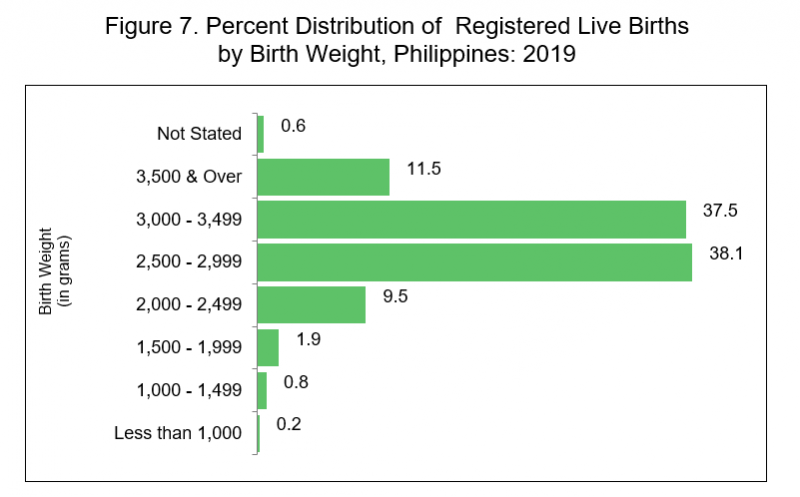

In [310]:
# Add birthweight and ageday columns for all the newborns
bw_dist = [random.randrange(5, 9)/10 for i in range(2)] + \
[random.randrange(11, 14)/10 for i in range(8)] + \
[random.randrange(16, 19)/10 for i in range(19)] + \
[random.randrange(21, 24)/10 for i in range(95)] + \
[random.randrange(26, 29)/10 for i in range(381)] + \
[random.randrange(31, 34)/10 for i in range(375)] + \
[random.randrange(35, 40)/10 for i in range(115)] + \
[random.randrange(5, 40)/10 for i in range(6)]

zero_mask = (df.pat_age >= 0) & (df.pat_age < 1)

# Generate age in days
df.loc[:, 'pat_ageday'] = 0
df.loc[zero_mask, 'pat_ageday'] = 3

# Generate birthweight
df.loc[:, 'pat_birthweight'] = 0
df.loc[zero_mask, 'pat_birthweight'] = df.loc[zero_mask, 'pat_birthweight'].swifter.apply(lambda x: random.choice(bw_dist))

Pandas Apply:   0%|          | 0/32969 [00:00<?, ?it/s]

In [311]:
## Check Output
df.loc[zero_mask, ["pat_ageday", "pat_birthweight"]]

,pat_ageday,pat_birthweight
11,3,1.7
17,3,3.8
20,3,2.8
33,3,2.7
44,3,2.6
...,...,...
249969,3,2.2
249972,3,2.7
249973,3,2.8
249989,3,3.2


### **2. Dataset Housekeeping**

In [312]:
### Drop unneeded columns
# clin_icd* and clin_c1* columns
df.drop(df.columns[(df.columns.str.contains('clin_icd'))], inplace=True, axis=1)
df.drop(["clin_c1", "clin_c2"], inplace=True, axis=1)

In [313]:
### Retype variables to decrease memory consumption
df.loc[df['pat_age'].notnull(), 'pat_age'] = df.loc[df['pat_age'].notnull(), 'pat_age'].astype(int)
df['pat_ageday'] = df['pat_ageday'].astype('int')
df['pat_birthweight'] = df['pat_birthweight'].astype('float32')
df['pdx_code'] = df['pdx_code'].astype('int16')

In [314]:
## Rename variables
col_rename = {
        'pdx': 'clin_pdx',
        'pdx_code' : 'clin_pdx_code',
        'icd_list' : 'clin_sdx',
        'icd9_list' : 'clin_proc',
        'rvs_list': 'xorig_rvs',
        'rvs_unmap_list': 'xrvs_unmap',
        'clin_cr1_rvs': 'xcr1_rvs',
        'clin_cr2_rvs': "xcr2_rvs"
    }
# "inplace=True" is indicated to modify columns within existing dataframe.
df.rename(columns=col_rename, inplace=True)

In [315]:
## Re-Order Variables
order = ['year_to_load', 'month', 'id_series', 'id_pin',  # ID variables
         'date_adm', 'date_dis', 'date_rec', # Date and time stamps
         'pat_type', 'pat_type_rel', 'pat_sex', 'pat_bdate', 'pat_age',  # Patient data
         'pat_accomodation', 'pat_cat', 'pat_cat2',
         'pat_ageday', 'pat_birthweight',
         'clin_pdx', 'clin_pdx_code', 'clin_sdx', 'clin_proc', 'clin_discharge', #'clin_los', # Grouper Dx & Proc
         'claims_amount', 'claims_charge', # PhilHealth reimbursements and hospital charge
         'xorig_cr1', 'xorig_cr2', "xorig_icd", 'xorig_rvs', 'xrvs_unmap', # Data quality tags
         'xcr1_rvs', 'xcr2_rvs'
         ]
len(order)


31

In [316]:
## Copy and check
# df2 = df[order].copy()
# df2.info()

In [317]:
## Check dataset
# df.iloc[0:20, 0:20]
# df.iloc[0:20, 21:40]

In [318]:
# ## Clear up RAM
# del(df)
# df = df2.copy()
# del(df2)
# gc.collect()

### **Checkpoint: Pickle and save `claims_clean_{year_to_load}` to GCS**

In [322]:
## Check everything
df.info()
gc.collect()
pd.set_option('display.max_columns', None)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   id_series          250000 non-null  string  
 1   id_pin             250000 non-null  string  
 2   date_adm           250000 non-null  object  
 3   time_adm           249996 non-null  object  
 4   date_dis           250000 non-null  object  
 5   time_dis           249996 non-null  object  
 6   date_rec           249981 non-null  object  
 7   date_ref           28799 non-null   object  
 8   date_check         232705 non-null  object  
 9   id_hci             250000 non-null  string  
 10  clin_outpatient    249996 non-null  category
 11  pat_type           250000 non-null  category
 12  clin_acc           241331 non-null  category
 13  pat_rel            96354 non-null   category
 14  pat_bdate          195052 non-null  object  
 15  pat_age            250000 non-null

,id_series,id_pin,date_adm,time_adm,date_dis,time_dis,date_rec,date_ref,date_check,id_hci,clin_outpatient,pat_type,clin_acc,pat_rel,pat_bdate,pat_age,pat_sex,pat_memcat_parent,pat_memcat_child,clin_discharge,claim_status,claim_payout,claim_charge,xorig_cr1,xorig_cr2,xorig_rvs,xcr1_rvs,xcr2_rvs,clin_sdx,xorig_icd,clin_proc,xrvs_unmap,clin_pdx,clin_pdx_code,pat_ageday,pat_birthweight
0,0000047245381,00000000000016826399,11/20/2018,18:00,11/25/2018,15:15,01/04/2019,NaN,01/10/2019,231701,0,DEP,W,C,NaN,10.0,M,INDIRECT,INDIGENT,1,PAID,10000.0,6918.500000,A971,NA,[],NaN,NaN,,[A971],,,NaN,99,0,0.0
1,0000024403330,00000000000008432267,12/27/2018,19:20,01/08/2019,15:50,03/07/2019,NaN,03/19/2019,520101,0,MEM,W,NaN,02/12/1950,68.0,M,INDIRECT,INDIGENT,1,PAID,18900.0,32022.919922,I219,NA,[],NaN,NaN,I499,"[I219, I499]",,,I219,1,0,0.0
2,0000041400502,00000000000015013020,04/09/2018,07:00,04/09/2018,00:00,06/07/2018,NaN,11/06/2018,640129,1,MEM,P,NaN,02/24/1953,65.0,F,INDIRECT,SENIOR,1,PAID,2600.0,4800.000000,90935,NA,[90935],True,NaN,Z491,"[N185, Z491]",3995,,N185,6,0,0.0
3,0000002788291,00000000000001023751,04/06/2018,08:00,04/09/2018,08:00,05/24/2018,NaN,07/31/2018,312435,1,MEM,P,NaN,11/20/1953,64.0,M,INDIRECT,SENIOR,1,PAID,5200.0,5200.000000,90935,NA,[90935],True,NaN,N185,"[N185, Z491]",3995,,Z491,6,0,0.0
4,0000043010321,00000000000015425482,09/12/2018,06:57,09/12/2018,10:29,10/15/2018,NaN,10/25/2018,Z00504,1,MEM,P,NaN,01/18/1955,63.0,M,INDIRECT,SENIOR,1,PAID,2600.0,2600.000000,90935,NA,[90935],True,NaN,,[N185],3995,,N185,3,0,0.0


In [320]:
## Pickle files - data type of each column is retained when we save and load the DataFrame
# https://www.statology.org/pandas-save-dataframe/#:~:text=The%20benefit%20of%20using%20pickle,original%20state%20of%20the%20DataFrame.
# clean_file = f'claims_clean_{year_to_load}.pkl'
# df.to_pickle(clean_file)
# !gsutil cp $clean_file 'gs://04_processed_claims_for_grouper/'

In [321]:
# Define a function to handle conversion
def list_to_string(x):
    if isinstance(x, list):
        return '|'.join(x)
    return ''

# Apply the function to convert list columns to string format "x|y|z"
df['clin_sdx'] = df['clin_sdx'].apply(list_to_string)
df['clin_proc'] = df['clin_proc'].apply(list_to_string)
df['xrvs_unmap'] = df['xrvs_unmap'].apply(list_to_string)

df.to_csv(path_inter / ("python_output_{}.csv".format(year_to_load)))

In [160]:
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total execution time: {elapsed_time} seconds")


Total execution time: 74.70053005218506 seconds
